# Resultados

In [140]:
# Importamos librerias a utilizar
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import time
import faiss
from matplotlib import pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, RegressorMixin
# KNN
from sklearn.neighbors import KNeighborsRegressor
# Linear Regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
# Random Forest
from sklearn.ensemble import RandomForestRegressor
# XGBoost
from xgboost import XGBRegressor
# SVR
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from sklearn.svm import LinearSVR
from sklearn.kernel_approximation import RBFSampler
# Machine Learning Models
from sklearn.neural_network import MLPRegressor
import datetime
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from keras.layers import Dense, Input, Dropout, SimpleRNN, Bidirectional, LSTM, Attention, Multiply, Conv1D, Flatten
from keras.models import Model
from keras.models import load_model, Sequential
from keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import re
from joblib import dump, load
import joblib
from functools import partial

In [2]:
# importamos datos
filename = 'C:/Users/luis_/Desktop\MaestriaEstadisticaAplicada/_8MachineLearning/proyecto_ml/datos/datos_oleaje.xlsx'
data = pd.read_excel(filename)

In [3]:
# Variables de entrada y salida
X = data.drop(columns=["P", "date_time"])  # Características
Y = data["P"].values # Variable objetivo

In [4]:
# División en datos de entrenamiento y validación (85%), y prueba (15%)
n = len(X)
train_size = int(n * 0.85)

Y_train, Y_test = Y[:train_size], Y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

In [5]:
# Definiendo la función para calcular MAPE, MAE, MSE y RMSE
def forecast_accuracy(forecast, actual, str_name):
    
    mask = actual != 0
    mape = np.mean(np.abs(forecast[mask] - actual[mask])/np.abs(actual[mask])) # MAPE
    mae = np.mean(np.abs(forecast - actual))                 # MAE
    rmse = np.mean((forecast - actual)**2)**.5               # RMSE
    mse = np.mean((forecast - actual)**2)                    # MSE
    
    df_acc = pd.DataFrame({'MAE': [mae],
                           'MAPE': [mape],
                           'MSE': [mse],
                           'RMSE': [rmse]},
                          index=[str_name])
    
    return df_acc

## 1. KNN Regression

### Ajuste del Modelo

In [106]:
# Pipiline del modelo
knn_pipeline = make_pipeline(
    StandardScaler(),        # Normalización de las características
    KNeighborsRegressor()    # Modelo KNN para regresión
)

#### Modelo Estándar

In [8]:
# Grid de hiperparámetros para KNN
knn_param_grid = {
    'kneighborsregressor': [KNeighborsRegressor(algorithm='brute')],
    'kneighborsregressor__n_neighbors': [3, 5, 7, 10, 15, 20],  # Número de vecinos
    'kneighborsregressor__weights': ['uniform', 'distance'],  # Tipo de ponderación (uniforme o por distancia)
    'kneighborsregressor__metric': ['euclidean', 'manhattan']  # Métrica de distancia (Euclidiana o Manhattan)
}

In [22]:
# Realizar GridSearchCV para encontrar los mejores hiperparámetros de KNN
knn_gs = GridSearchCV(knn_pipeline, knn_param_grid, cv=5)
start_fit = time.time()
knn_gs.fit(X_train, Y_train)   
end_fit = time.time()

In [31]:
# Imprimir los mejores parámetros, el rendimiento y el tiempo
print(f"Mejores parámetros de KNN: {knn_gs.best_params_}")
print(f"Mejor puntuación de KNN: {knn_gs.best_score_}")
print(f"Fit Time (s): : {round(end_fit - start_fit, 4)}")

Mejores parámetros de KNN: {'kneighborsregressor': KNeighborsRegressor(algorithm='brute'), 'kneighborsregressor__metric': 'euclidean', 'kneighborsregressor__n_neighbors': 3, 'kneighborsregressor__weights': 'distance'}
Mejor puntuación de KNN: 0.9679175542550382
Fit Time (s): : 298.5188


In [24]:
# Resultados con conjunto de test
print("Test score: {:.4f}".format(knn_gs.score(X_test, Y_test)))

Test score: 0.9460


#### KD-Trees

In [9]:
# Grid de hiperparámetros para KNN
knn_param_grid_kd = {
    'kneighborsregressor': [KNeighborsRegressor(algorithm='kd_tree')], # algoritmos de optimización KD-Tree
    'kneighborsregressor__n_neighbors': [3, 5, 7, 10, 15, 20],  # Número de vecinos
    'kneighborsregressor__weights': ['uniform', 'distance'],  # Tipo de ponderación (uniforme o por distancia)
    'kneighborsregressor__metric': ['euclidean', 'manhattan']  # Métrica de distancia (Euclidiana o Manhattan)
}

In [11]:
# Realizar GridSearchCV para encontrar los mejores hiperparámetros de KNN
knn_gs_kd = GridSearchCV(knn_pipeline, knn_param_grid_kd, cv=5)
start_fit_kd = time.time()
knn_gs_kd.fit(X_train, Y_train)   
end_fit_kd = time.time()
joblib.dump(knn_gs_kd.best_estimator_, 'best_knn_model.joblib')
print(f"Modelo guardado como {'best_knn_model.joblib'}")

Modelo guardado como best_knn_model.joblib


In [12]:
# Imprimir los mejores parámetros, el rendimiento y el tiempo
print(f"Mejores parámetros de KNN: {knn_gs_kd.best_params_}")
print(f"Mejor puntuación de KNN: {knn_gs_kd.best_score_}")
print(f"Fit Time (s): : {round(end_fit_kd - start_fit_kd, 4)}")

Mejores parámetros de KNN: {'kneighborsregressor': KNeighborsRegressor(algorithm='kd_tree'), 'kneighborsregressor__metric': 'euclidean', 'kneighborsregressor__n_neighbors': 3, 'kneighborsregressor__weights': 'distance'}
Mejor puntuación de KNN: 0.967917555014935
Fit Time (s): : 101.5738


In [13]:
# Resultados con conjunto de test
print("Test score: {:.4f}".format(knn_gs_kd.score(X_test, Y_test)))

Test score: 0.9209


#### Ball Trees

In [33]:
# Grid de hiperparámetros para KNN
knn_param_grid_bt = {
    'kneighborsregressor': [KNeighborsRegressor(algorithm='ball_tree')], # algoritmos de optimización Ball Trees
    'kneighborsregressor__n_neighbors': [3, 5, 7, 10, 15, 20],  # Número de vecinos
    'kneighborsregressor__weights': ['uniform', 'distance'],  # Tipo de ponderación (uniforme o por distancia)
    'kneighborsregressor__metric': ['euclidean', 'manhattan']  # Métrica de distancia (Euclidiana o Manhattan)
}

In [34]:
# Realizar GridSearchCV para encontrar los mejores hiperparámetros de KNN
knn_gs_bt = GridSearchCV(knn_pipeline, knn_param_grid_bt, cv=5)
start_fit_bt = time.time()
knn_gs_bt.fit(X_train, Y_train)   
end_fit_bt = time.time()

In [35]:
# Imprimir los mejores parámetros, el rendimiento y el tiempo
print(f"Mejores parámetros de KNN: {knn_gs_bt.best_params_}")
print(f"Mejor puntuación de KNN: {knn_gs_bt.best_score_}")
print(f"Fit Time (s): : {round(end_fit_bt - start_fit_bt, 4)}")

Mejores parámetros de KNN: {'kneighborsregressor': KNeighborsRegressor(algorithm='ball_tree'), 'kneighborsregressor__metric': 'euclidean', 'kneighborsregressor__n_neighbors': 3, 'kneighborsregressor__weights': 'distance'}
Mejor puntuación de KNN: 0.9679175488095119
Fit Time (s): : 402.721


In [36]:
# Resultados con conjunto de test
print("Test score: {:.4f}".format(knn_gs_bt.score(X_test, Y_test)))

Test score: 0.9209


#### FAISS

In [ ]:
# Se crea función knn con faiss
class FaissKNNRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, n_neighbors=5, weights='uniform', metric='euclidean'):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metric = metric

    def fit(self, X, y):
        self.X_train_ = np.ascontiguousarray(X.astype('float32'))
        self.y_train_ = y

        if self.metric == 'euclidean':
            self.index = faiss.IndexFlatL2(self.X_train_.shape[1])
        elif self.metric == 'manhattan':
            self.index = faiss.IndexFlat(self.X_train_.shape[1])
        else:
            raise ValueError("Unsupported metric: choose 'euclidean' or 'manhattan'.")

        self.index.add(self.X_train_)
        return self

    def predict(self, X):
        X = np.ascontiguousarray(X.astype('float32'))
        distances, indices = self.index.search(X, self.n_neighbors)
        y_pred = np.zeros(X.shape[0])

        for i, neighbors in enumerate(indices):
            neighbor_values = self.y_train_[neighbors]

            if self.weights == 'uniform':
                y_pred[i] = np.mean(neighbor_values)
            elif self.weights == 'distance':
                dists = distances[i]
                # Evitar división por cero
                weights = 1 / (dists + 1e-8)
                y_pred[i] = np.average(neighbor_values, weights=weights)
            else:
                raise ValueError("weights must be 'uniform' or 'distance'")

        return y_pred

In [111]:
# pipeline para faiss
knn_pipeline_faiss = make_pipeline(StandardScaler(), FaissKNNRegressor())

In [112]:
# Grid de hiperparámetros para KNN
knn_param_grid_faiss = {
    'faissknnregressor__n_neighbors': [3, 5, 7, 10, 15, 20],
    'faissknnregressor__weights': ['uniform', 'distance'],
    'faissknnregressor__metric': ['euclidean', 'manhattan']
}

In [113]:
# Realizar GridSearchCV para encontrar los mejores hiperparámetros de KNN
knn_gs_faiss = GridSearchCV(knn_pipeline_faiss, knn_param_grid_faiss, cv=5)
start_fit_faiss = time.time()
knn_gs_faiss.fit(X_train, Y_train)   
end_fit_faiss = time.time()

In [114]:
# Imprimir los mejores parámetros, el rendimiento y el tiempo
print(f"Mejores parámetros de KNN: {knn_gs_faiss.best_params_}")
print(f"Mejor puntuación de KNN: {knn_gs_faiss.best_score_}")
print(f"Fit Time (s): : {round(end_fit_faiss - start_fit_faiss, 4)}")

Mejores parámetros de KNN: {'faissknnregressor__metric': 'euclidean', 'faissknnregressor__n_neighbors': 3, 'faissknnregressor__weights': 'distance'}
Mejor puntuación de KNN: 0.9685161038715389
Fit Time (s): : 133.0474


### Forecast Accuracy

In [115]:
# Se carga el mejor modelo
knn_best_model = joblib.load('best_knn_model.joblib')

In [116]:
# Se hacen las predicciones
y_test_knn_pred = knn_best_model.predict(X_test)

In [117]:
# Se calculan las metricas
forecast_accuracy( np.array(y_test_knn_pred), np.array(Y_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,1165.844368,0.379255,3.352590e+07,5790.155204


In [118]:
# Se calcula r^2
r2 = r2_score(Y_test, y_test_knn_pred)
print(f"R²: {r2:.4f}")

R²: 0.9209


### Gráfica de diagnóstico

In [119]:
# Residuales de modelo
residuals_knn = Y_test - y_test_knn_pred

In [120]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_knn, lags=[144], return_df=True)
print(lb_test)

          lb_stat  lb_pvalue
144  24396.513393        0.0


In [121]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_knn)

SignificanceResult(statistic=40168258820.98496, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


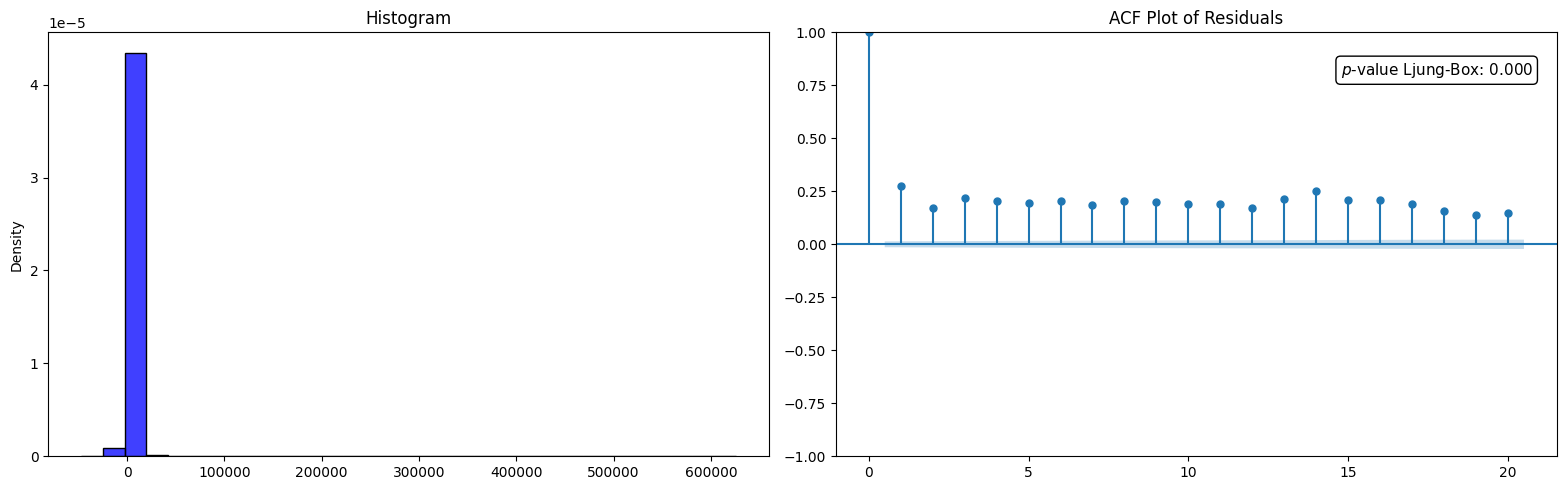

In [122]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_knn, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_knn, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

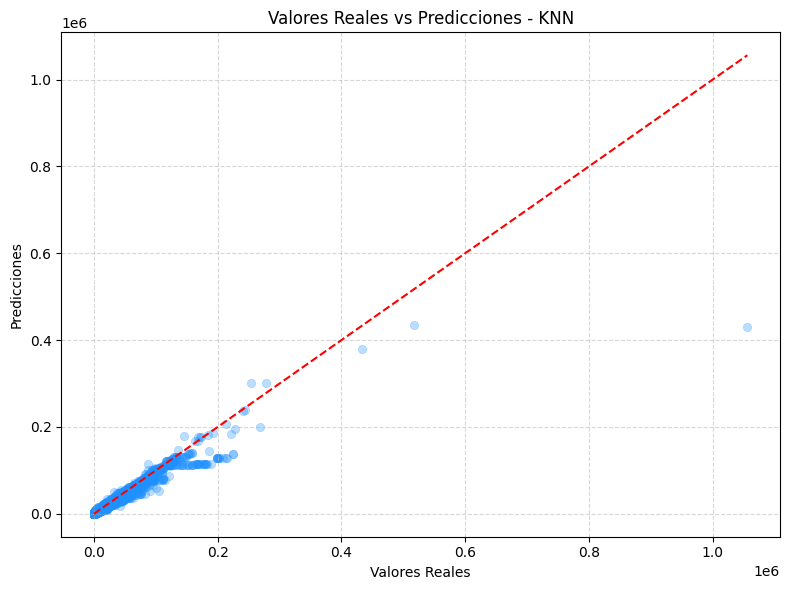

In [123]:
# Gráfico de valores predichos vs observados
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_test_knn_pred, alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - KNN")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Linear Regression

### Ajuste del Modelo

In [13]:
# Pipiline del modelo
pipeline = make_pipeline(
    StandardScaler(),  # Normalización de las características
    LinearRegression()  # Modelo de regresión lineal
)

In [15]:
# Aplicando validación cruzada
cv_scores = cross_val_score(pipeline, X_train, Y_train, cv=5)

In [16]:
print("Cross-validation scores:\n{}".format(cv_scores))

Cross-validation scores:
[0.78141476 0.82146826 0.71783811 0.82203402 0.84612813]


In [17]:
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [30]:
print("Test score: {:.4f}".format(pipeline.score(X_train, Y_train)))

Test score: 0.7995


In [31]:
print("Test score: {:.4f}".format(pipeline.score(X_test, Y_test)))

Test score: 0.6951


### Forecast Accuracy

In [18]:
y_test_lr_pred = pipeline.predict(X_test)

In [19]:
forecast_accuracy( np.array(y_test_lr_pred), np.array(Y_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,4543.57517,543.35166,1.292470e+08,11368.685353


In [20]:
# Se calcula r^2
r2 = r2_score(Y_test, y_test_lr_pred)
print(f"R²: {r2:.4f}")

R²: 0.6951


### Gráfica de diagnóstico

In [43]:
# Residuales de modelo
residuals_lr = Y_test - y_test_lr_pred

In [44]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_lr, lags=[144], return_df=True)
print(lb_test)

          lb_stat  lb_pvalue
144  93376.268403        0.0


In [45]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_lr)

SignificanceResult(statistic=4716660929.341942, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


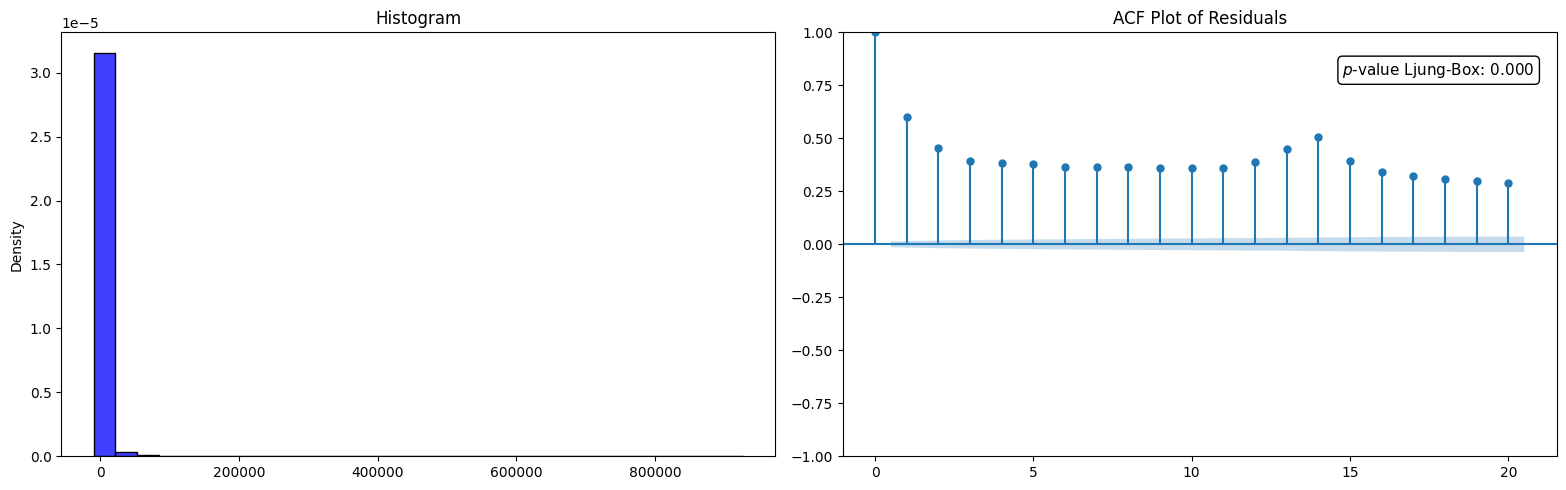

In [46]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_lr, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_lr, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

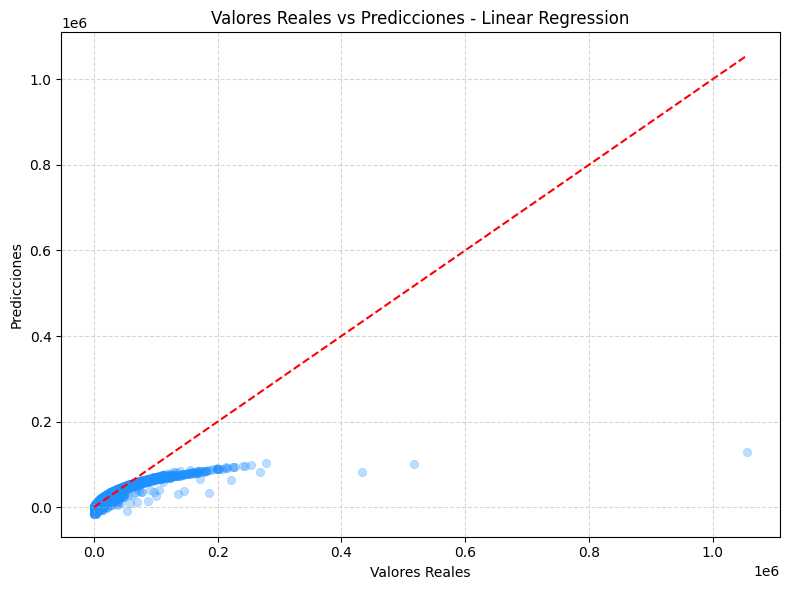

In [50]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_test_lr_pred, alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - Linear Regression")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Ridge Regression

### Ajuste del Modelo

In [21]:
# Pipeline con Ridge Regression
ridge_pipeline = make_pipeline(
    StandardScaler(),  # Normalización de las características
    Ridge()             # Modelo de regresión Ridge
)

#### Cholesky (Estándar)

In [22]:
# Grid de hiperparámetros para Ridge
ridge_param_grid = {
    'ridge__solver': ['cholesky'],
    'ridge__alpha': [0.1, 1.0, 10.0, 100.0]  # Parámetros alpha de Ridge
}

In [23]:
# Realizando GridSearchCV
ridge_gs = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5)
start_fit_ridge = time.time()
ridge_gs.fit(X_train, Y_train)
end_fit_ridge = time.time()

In [24]:
# Imprimir los mejores parámetros y el rendimiento
print(f"Mejores parámetros de Ridge: {ridge_gs.best_params_}")
print(f"Mejor puntuación de Ridge: {ridge_gs.best_score_}")
print(f"Fit Time (s): : {round(end_fit_ridge - start_fit_ridge, 4)}")

Mejores parámetros de Ridge: {'ridge__alpha': 100.0, 'ridge__solver': 'cholesky'}
Mejor puntuación de Ridge: 0.7978181128476038
Fit Time (s): : 0.319


In [56]:
# Resultados con conjunto de test
print("Test score: {:.4f}".format(ridge_gs.score(X_test, Y_test)))

Test score: 0.6950


#### Saga

In [124]:
# Grid de hiperparámetros para Ridge
ridge_param_grid_sag = {
    'ridge__solver': ['saga'], 
    'ridge__alpha': [0.1, 1.0, 10.0, 100.0]  # Parámetros alpha de Ridge
}

In [125]:
# Realizando GridSearchCV
ridge_gs_sag = GridSearchCV(ridge_pipeline, ridge_param_grid_sag, cv=5)
start_fit_ridge_sag = time.time()
ridge_gs_sag.fit(X_train, Y_train)
end_fit_ridge_sag = time.time()

In [126]:
# Imprimir los mejores parámetros y el rendimiento
print(f"Mejores parámetros de Ridge: {ridge_gs_sag.best_params_}")
print(f"Mejor puntuación de Ridge: {ridge_gs_sag.best_score_}")
print(f"Fit Time (s): : {round(end_fit_ridge_sag - start_fit_ridge_sag, 4)}")

Mejores parámetros de Ridge: {'ridge__alpha': 100.0, 'ridge__solver': 'saga'}
Mejor puntuación de Ridge: 0.7978184516025794
Fit Time (s): : 2.4807


In [127]:
# Resultados con conjunto de test
print("Test score: {:.4f}".format(ridge_gs_sag.score(X_test, Y_test)))

Test score: 0.6950


### Forecast Accuracy

In [25]:
# Evaluación en el conjunto de prueba para Ridge
y_test_ridge_pred = ridge_gs.predict(X_test)

In [26]:
# Se calculan las métricas de precisión
forecast_accuracy( np.array(y_test_ridge_pred), np.array(Y_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,4541.339648,549.324694,1.293073e+08,11371.338221


In [27]:
# Se calcula r^2
r2 = r2_score(Y_test, y_test_ridge_pred)
print(f"R²: {r2:.4f}")

R²: 0.6950


### Gráfica de diagnóstico

In [61]:
# Residuales de modelo
residuals_ridge = Y_test - y_test_ridge_pred

In [62]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_ridge, lags=[144], return_df=True)
print(lb_test)


          lb_stat  lb_pvalue
144  93453.953875        0.0


In [63]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_ridge)

SignificanceResult(statistic=4704772783.13706, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


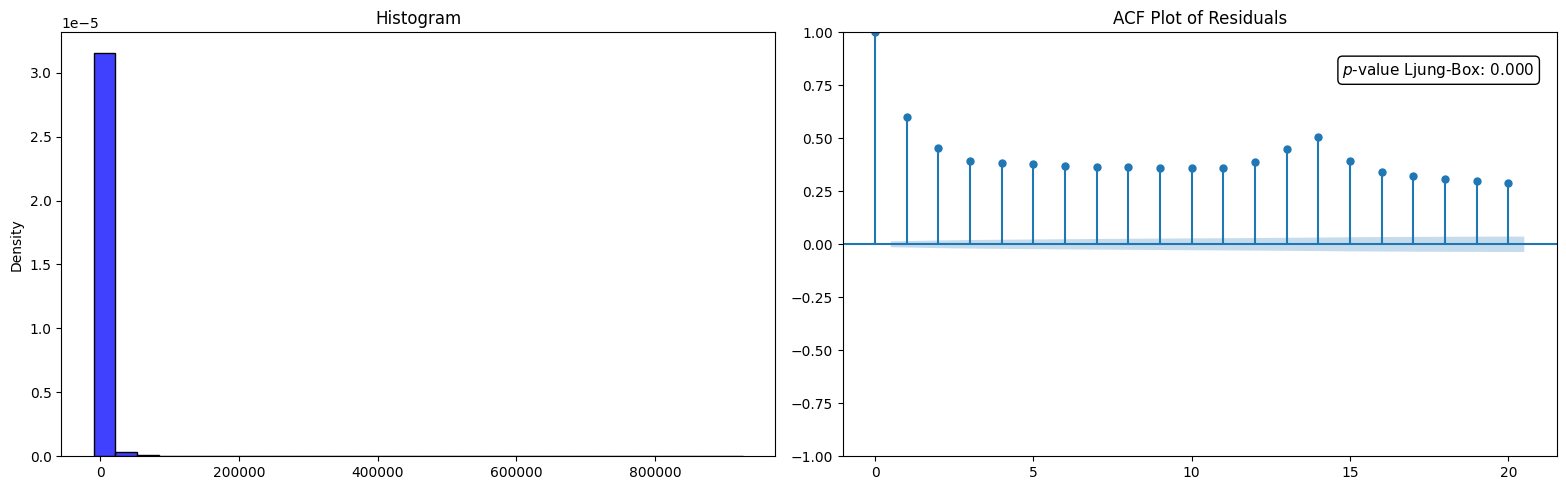

In [64]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_ridge, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_ridge, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

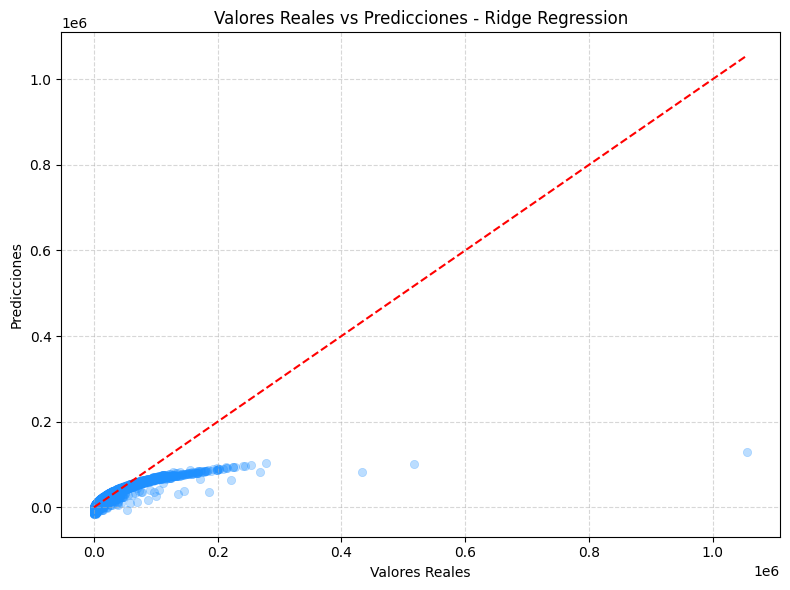

In [65]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_test_ridge_pred, alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - Ridge Regression")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Lasso Regression

### Ajuste del Modelo

In [28]:
# Pipeline con Lasso Regression
lasso_pipeline = make_pipeline(
    StandardScaler(),  # Normalización de las características
    Lasso()             # Modelo de regresión Lasso
)

####  Modelo Estándar

In [29]:
# Grid de hiperparámetros para Lasso
lasso_param_grid = {
    'lasso__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]  # Parámetros alpha de Lasso
}

In [30]:
# Realizar GridSearchCV para encontrar el mejor valor de alpha para Lasso
lasso_gs = GridSearchCV(lasso_pipeline, lasso_param_grid, cv=5)
start_fit_lasso = time.time()
lasso_gs.fit(X_train, Y_train)
end_fit_lasso = time.time()

In [31]:
# Imprimir los mejores parámetros y el rendimiento
print(f"Mejores parámetros de Lasso: {lasso_gs.best_params_}")
print(f"Mejor puntuación MSE (negativo) de Lasso: {lasso_gs.best_score_}")
print(f"Fit Time (s): : {round(end_fit_lasso - start_fit_lasso, 4)}")

Mejores parámetros de Lasso: {'lasso__alpha': 10.0}
Mejor puntuación MSE (negativo) de Lasso: 0.79783473177455
Fit Time (s): : 1.7355


In [32]:
# Resultados con conjunto de test
print("Test score: {:.4f}".format(lasso_gs.score(X_test, Y_test)))

Test score: 0.6951


#### Saga

In [72]:
lasso_pipeline_sag = make_pipeline(
    StandardScaler(),
    SGDRegressor(penalty='l1', loss='squared_error')
)

In [73]:
# Grid de hiperparámetros para Lasso con saga
lasso_param_grid_sag = {
    'sgdregressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]  # Parámetros alpha de Lasso
}

In [74]:
# Realizar GridSearchCV para encontrar el mejor valor de alpha para Lasso
lasso_gs_sag = GridSearchCV(lasso_pipeline_sag, lasso_param_grid_sag, cv=5)
start_fit_lasso_sag = time.time()
lasso_gs_sag.fit(X_train, Y_train)
end_fit_lasso_sag = time.time()

In [75]:
# Imprimir los mejores parámetros y el rendimiento
print(f"Mejores parámetros de Lasso: {lasso_gs_sag.best_params_}")
print(f"Mejor puntuación MSE (negativo) de Lasso: {lasso_gs_sag.best_score_}")
print(f"Fit Time (s): : {round(end_fit_lasso_sag - start_fit_lasso_sag, 4)}")

Mejores parámetros de Lasso: {'sgdregressor__alpha': 10.0}
Mejor puntuación MSE (negativo) de Lasso: 0.79792505948813
Fit Time (s): : 3.4854


In [80]:
# Resultados con conjunto de test
print("Test score: {:.4f}".format(lasso_gs_sag.score(X_test, Y_test)))

Test score: 0.6933


### Forecast Accuracy

In [33]:
# Evaluación en el conjunto de prueba para Lasso
y_test_lasso_pred = lasso_gs.predict(X_test)

In [34]:
# Se calculan las métricas de precisión
forecast_accuracy( np.array(y_test_lasso_pred), np.array(Y_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,4544.543462,551.847153,1.292687e+08,11369.638859


In [35]:
# Se calcula r^2
r2 = r2_score(Y_test, y_test_lasso_pred)
print(f"R²: {r2:.4f}")

R²: 0.6951


### Gráfica de diagnóstico

In [83]:
# Residuales de modelo
residuals_lasso = Y_test - y_test_lasso_pred

In [84]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_lasso, lags=[144], return_df=True)
print(lb_test)

          lb_stat  lb_pvalue
144  93409.759283        0.0


In [85]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_lasso)

SignificanceResult(statistic=4706614753.434224, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


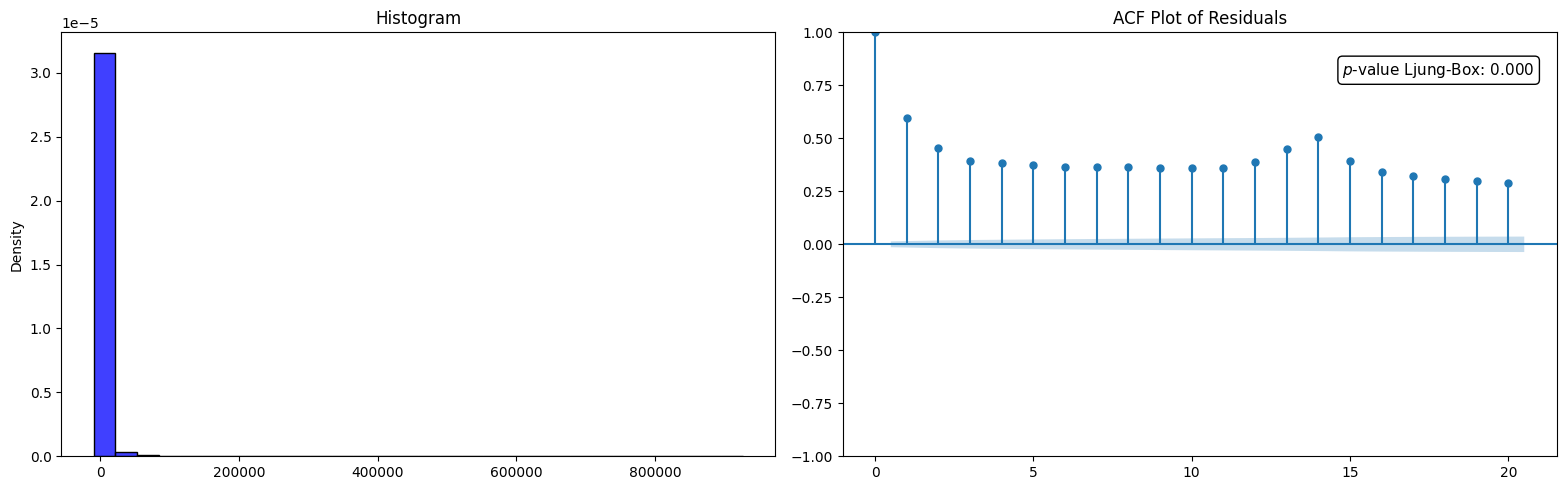

In [86]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_lasso, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_lasso, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()


### Gráfica de predichos vs observados

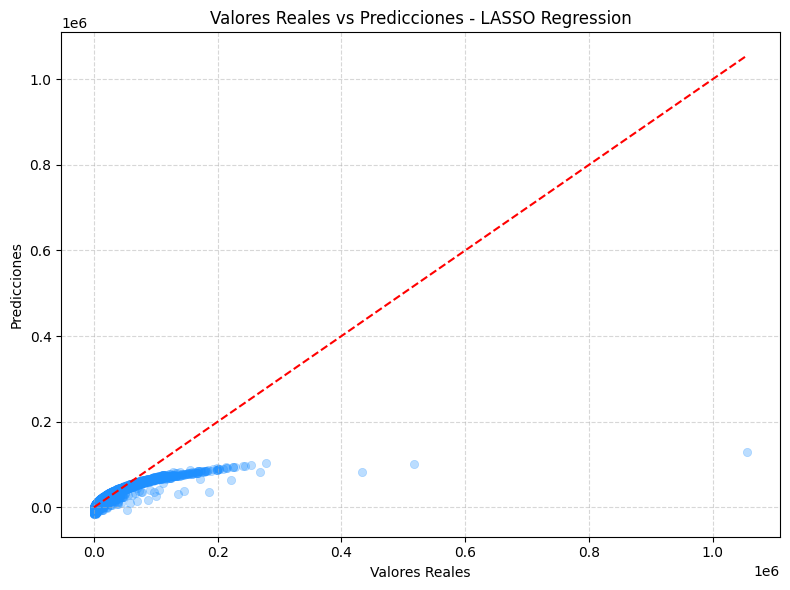

In [87]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_test_lasso_pred, alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - LASSO Regression")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Random Forest Regression

### Ajuste del Modelo

In [42]:
# Crear un pipeline con Random Forest Regression
rf_pipeline = make_pipeline(
    StandardScaler(),              # Normalización de las características
    RandomForestRegressor(random_state=42)  # Modelo Random Forest para regresión
)

In [43]:
# Grid de hiperparámetros para Random Forest
rf_param_grid = {
    'randomforestregressor__n_estimators': [50, 100, 200],  # Número de árboles en el bosque
    'randomforestregressor__max_depth': [3, 5, 10, 20, 30],  # Profundidad máxima de los árboles
}

In [ ]:
# Realizar GridSearchCV para Random Forest y guardar mejor modelo
model_filename = 'best_randomforest_model.pkl'
model = None

if os.path.exists(model_filename):
    print(f"El modelo ya existe. Cargando desde {model_filename}...")
    model = joblib.load(model_filename)
else:
    print("El modelo no existe. Entrenando un nuevo modelo...")
    rf_grid_search = GridSearchCV(rf_pipeline, rf_param_grid, cv=5)
    start_fit_rf = time.time()
    rf_grid_search.fit(X_train, Y_train)
    end_fit_rf = time.time()

    # Imprimir los mejores parámetros y el rendimiento
    print(f"Mejores parámetros de Random Forest: {rf_grid_search.best_params_}")
    print(f"Mejor puntuación de Random Forest: {rf_grid_search.best_score_}")
    print(f"Tiempo de cómputo (s): : {round(end_fit_rf - start_fit_rf, 4)}")

    joblib.dump(rf_grid_search.best_estimator_, model_filename)
    print(f"Modelo guardado como {model_filename}")
    
    model = rf_grid_search.best_estimator_

El modelo no existe. Entrenando un nuevo modelo...
Mejores parámetros de Random Forest: {'randomforestregressor__max_depth': 20, 'randomforestregressor__n_estimators': 200}
Mejor puntuación de Random Forest: 0.9923041769075145
Tiempo de cómputo (s): : 1791.2862
Modelo guardado como best_randomforest_model.pkl


In [ ]:
print("Score test: {:.4f}".format(rf_grid_search.score(X_test, Y_test)))

Score test: 0.9377


### Forecast Accuracy

In [36]:
# Se carga el mejor modelo
rf_best_model = joblib.load('best_randomforest_model.pkl')

In [37]:
# Se hacen las predicciones
y_test_rf_pred = rf_best_model.predict(X_test)

In [38]:
# Se calculan las métricas de precisión
forecast_accuracy( np.array(y_test_rf_pred), np.array(Y_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,135.747221,0.008834,2.640609e+07,5138.685191


In [39]:
# Se calcula r^2
r2 = r2_score(Y_test, y_test_rf_pred)
print(f"R²: {r2:.4f}")

R²: 0.9377


### Gráfica de importancia de variables

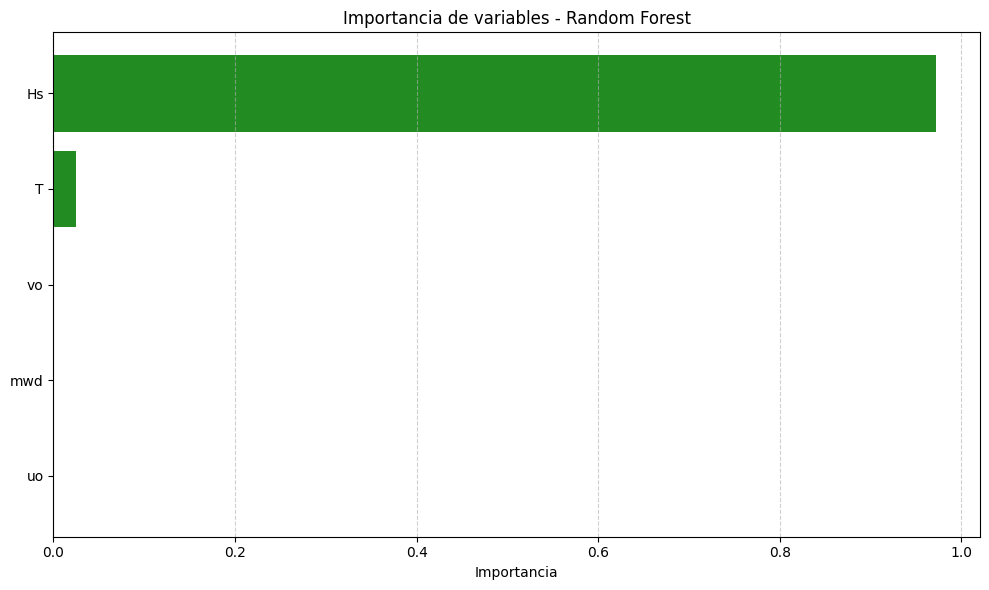

In [124]:
# Gráfica de importacia de variables
rf_best_model_features = rf_best_model.named_steps['randomforestregressor']
feature_names = X.columns
importances = rf_best_model_features.feature_importances_

feature_names1 = feature_names[2:]
importances1 = importances[2:]

# Ordenar
sorted_idx = np.argsort(importances1)[::-1]
sorted_features = feature_names1[sorted_idx]
sorted_importances = importances1[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances, color='forestgreen')
plt.xlabel('Importancia')
plt.title('Importancia de variables - Random Forest')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Gráfica de diagnóstico

In [125]:
# Residuales de modelo
residuals_rf = Y_test - y_test_rf_pred

In [126]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_rf, lags=[144], return_df=True)
print(lb_test)

         lb_stat      lb_pvalue
144  1606.096695  3.869683e-245


In [127]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_rf)

SignificanceResult(statistic=195103066798.90485, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


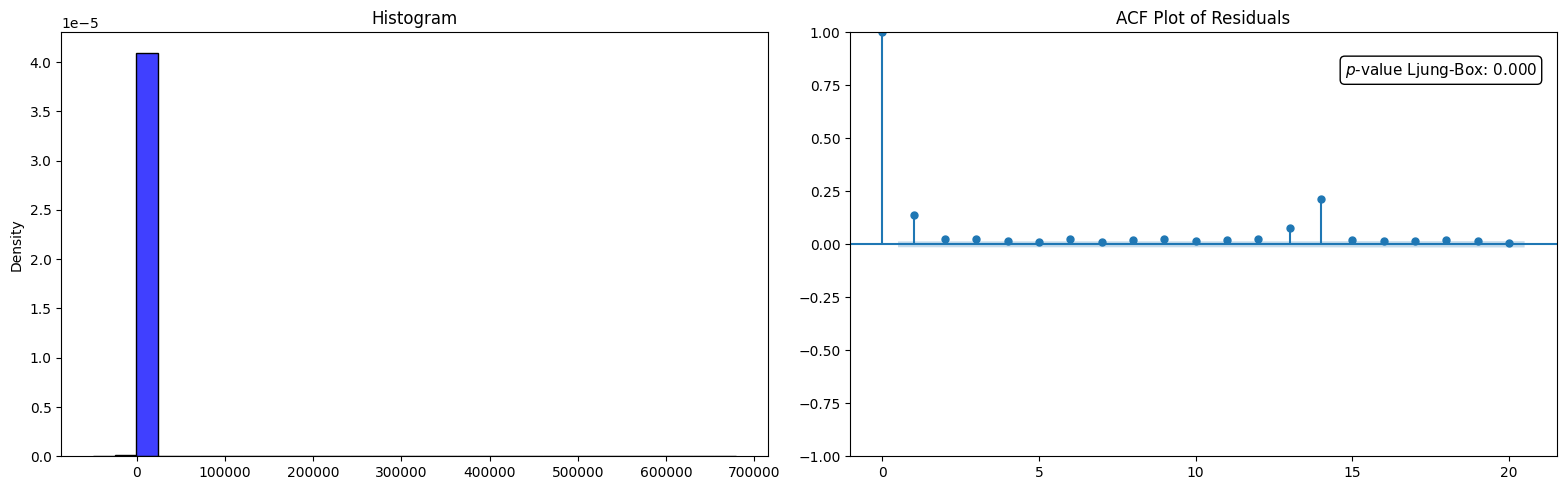

In [128]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_rf, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_rf, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()


### Gráfica de predichos vs observados

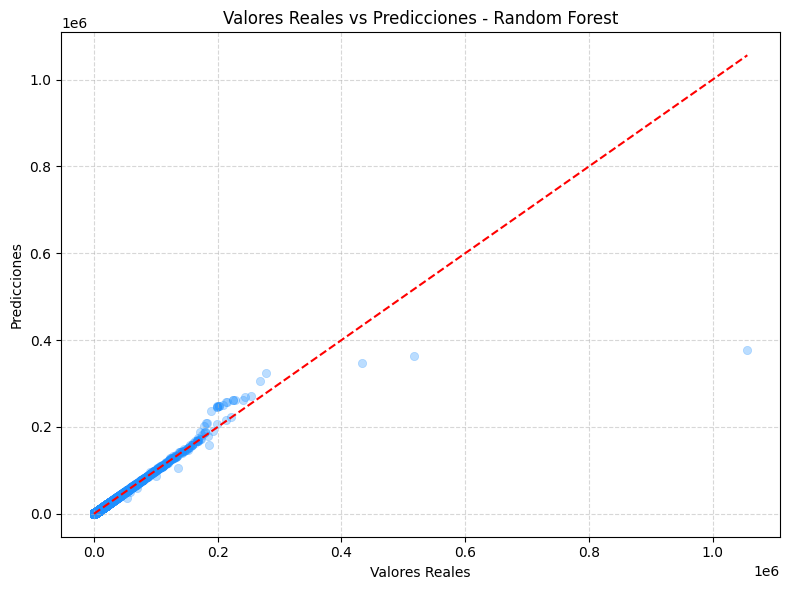

In [139]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_test_rf_pred, alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - Random Forest")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. XGBoost

### Ajuste del Modelo

In [65]:
# Crear un pipeline con XGBoost Regression
xgb_pipeline = make_pipeline(
    StandardScaler(),    # Normalización de las características
    XGBRegressor(random_state=42, objective='reg:squarederror')  # Modelo XGBoost para regresión
)

#### Modelo Estándar

In [ ]:
# Grid de hiperparámetros para XGBoost
xgb_param_grid = {
    'xgbregressor__n_estimators': [50, 100, 200],       # Número de árboles
    'xgbregressor__learning_rate': [0.1, 0.2, 0.3],    # Tasa de aprendizaje
    'xgbregressor__max_depth': [3, 5, 7, 10]           # Profundidad máxima de los árboles
}

In [ ]:
# Realizar GridSearchCV para XGBoost y guardar mejor modelo
model_filename = 'best_xgboost_model.pkl'
model = None

if os.path.exists(model_filename):
    print(f"El modelo ya existe. Cargando desde {model_filename}...")
    model = joblib.load(model_filename)
else:
    print("El modelo no existe. Entrenando un nuevo modelo...")
    xgb_grid_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=5)
    start_fit_xg = time.time()
    xgb_grid_search.fit(X_train, Y_train)
    end_fit_xg = time.time()

    # Imprimir los mejores parámetros y el rendimiento
    print(f"Mejores parámetros de XGBoost: {xgb_grid_search.best_params_}")
    print(f"Mejor puntuación de XGBoost: {xgb_grid_search.best_score_}")
    print(f"Tiempo de cómputo (s): : {round(end_fit_xg - start_fit_xg, 4)}")

    joblib.dump(xgb_grid_search.best_estimator_, model_filename)
    print(f"Modelo guardado como {model_filename}")
    
    model = xgb_grid_search.best_estimator_

El modelo no existe. Entrenando un nuevo modelo...
Mejores parámetros de Random Forest: {'xgbregressor__learning_rate': 0.2, 'xgbregressor__max_depth': 7, 'xgbregressor__n_estimators': 50}
Mejor puntuación de Random Forest: 0.9853301150360434
Tiempo de cómputo (s): : 45.1376
Modelo guardado como best_xgboost_model.pkl


In [70]:
print("Score test: {:.4f}".format(xgb_grid_search.score(X_test, Y_test)))

Score test: 0.8429


#### Usando tree_method='hist' y early_stopping_rounds

In [86]:
# Crear un pipeline con XGBoost Regression optimizado
xgb_pipeline_op = make_pipeline(
    StandardScaler(),    # Normalización de las características
    XGBRegressor(random_state=42, objective='reg:squarederror', tree_method = 'hist')  # Modelo XGBoost para regresión
)

In [ ]:
# Realizar GridSearchCV para XGBoost y guardar mejor modelo
model_filename = 'best_xgboost_model_op.pkl'
model = None

if os.path.exists(model_filename):
    print(f"El modelo ya existe. Cargando desde {model_filename}...")
    model = joblib.load(model_filename)
else:
    print("El modelo no existe. Entrenando un nuevo modelo...")
    xgb_grid_search_op = GridSearchCV(xgb_pipeline_op, xgb_param_grid, cv=5)
    start_fit_xg_op = time.time()
    xgb_grid_search_op.fit(X_train, Y_train)
    end_fit_xg_op = time.time()

    # Imprimir los mejores parámetros y el rendimiento
    print(f"Mejores parámetros de XGBoost: {xgb_grid_search_op.best_params_}")
    print(f"Mejor puntuación de XGBoost: {xgb_grid_search_op.best_score_}")
    print(f"Tiempo de cómputo (s): : {round(end_fit_xg_op - start_fit_xg_op, 4)}")

    joblib.dump(xgb_grid_search_op.best_estimator_, model_filename)
    print(f"Modelo guardado como {model_filename}")
    
    model = xgb_grid_search_op.best_estimator_

El modelo no existe. Entrenando un nuevo modelo...
Mejores parámetros de Random Forest: {'xgbregressor__learning_rate': 0.2, 'xgbregressor__max_depth': 7, 'xgbregressor__n_estimators': 50}
Mejor puntuación de Random Forest: 0.9853301150360434
Tiempo de cómputo (s): : 45.9525
Modelo guardado como best_xgboost_model_op.pkl


### Forecast Accuracy

In [40]:
# Se carga el mejor modelo
xgboost_best_model = joblib.load('best_xgboost_model.pkl')

In [41]:
# Se hacen las predicciones
y_test_xgboost_pred = xgboost_best_model.predict(X_test)

In [42]:
# Se calculan las métricas de precisión
forecast_accuracy( np.array(y_test_xgboost_pred), np.array(Y_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,532.191628,1.000625,6.660852e+07,8161.404138


In [43]:
# Se calcula r^2
r2 = r2_score(Y_test, y_test_xgboost_pred)
print(f"R²: {r2:.4f}")

R²: 0.8429


### Gráfica de diagnóstico

In [134]:
# Residuales de modelo
residuals_xgboost = Y_test - y_test_xgboost_pred

In [135]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_xgboost, lags=[144], return_df=True)
print(lb_test)

          lb_stat  lb_pvalue
144  54914.183191        0.0


In [136]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_xgboost)

SignificanceResult(statistic=4468031180.122305, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


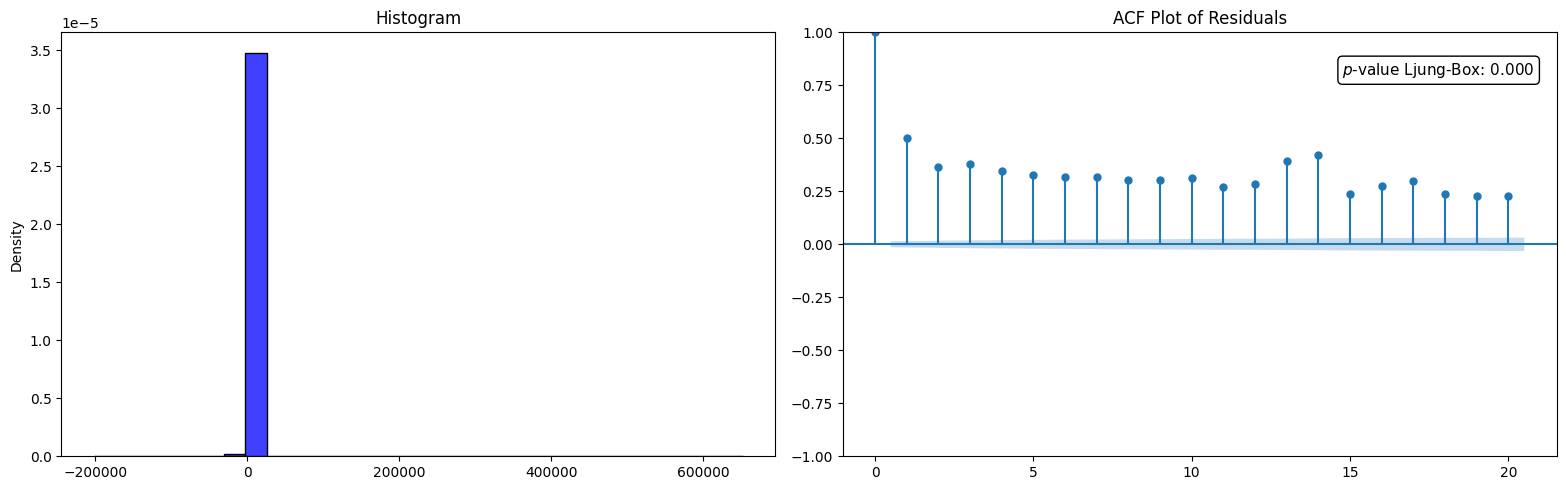

In [137]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_xgboost, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_xgboost, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

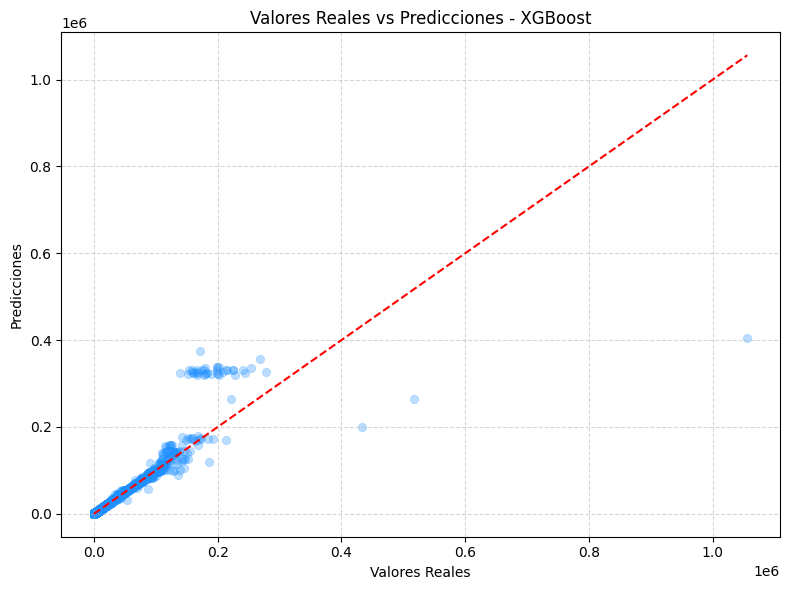

In [142]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_test_xgboost_pred, alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - XGBoost")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. SVR

### Ajuste del Modelo

#### Modelo Estándar

In [8]:
# Crear un pipeline con SVM  Regression
svr_pipeline = make_pipeline(
    StandardScaler(),    # Normalización de las características
    SVR()  # Modelo SVR
)

In [9]:
# Grid de hiperparámetros para SVM
svr_param_grid = {
    'svr__kernel': ['rbf'],
    'svr__C': [0.1, 1, 10],
    'svr__gamma': [0.1, 1, 10]
}

In [ ]:
# Realizar GridSearchCV para SVR y guardar mejor modelo
model_filename = 'best_svr_model.joblib'
model = None

if os.path.exists(model_filename):
    print(f"El modelo ya existe. Cargando desde {model_filename}...")
    model = joblib.load(model_filename)
else:
    print("El modelo no existe. Entrenando un nuevo modelo...")
    svr_grid_search = GridSearchCV(svr_pipeline, svr_param_grid, cv=5)
    start_fit_svr = time.time()
    svr_grid_search.fit(X_train, Y_train)
    end_fit_svr = time.time()

    # Imprimir los mejores parámetros y el rendimiento
    print(f"Mejores parámetros de SVR: {svr_grid_search.best_params_}")
    print(f"Mejor puntuación de SVR: {svr_grid_search.best_score_}")
    print(f"Tiempo de cómputo (s): : {round(end_fit_svr - start_fit_svr, 4)}")

    joblib.dump(svr_grid_search.best_estimator_, model_filename)
    print(f"Modelo guardado como {model_filename}")
    
    model = svr_grid_search.best_estimator_

El modelo no existe. Entrenando un nuevo modelo...
Mejores parámetros de Random Forest: {'svr__C': 10, 'svr__gamma': 0.1, 'svr__kernel': 'rbf'}
Mejor puntuación de Random Forest: 0.6330429922791502
Tiempo de cómputo (s): : 18565.4002
Modelo guardado como best_svr_model.joblib


In [ ]:
print("Score test: {:.4f}".format(svr_grid_search.score(X_test, Y_test)))

Score test: 0.4679


#### SVR con SGDRegressor

In [126]:
sgd_pipeline = make_pipeline(
    StandardScaler(),
    SGDRegressor(loss='epsilon_insensitive', max_iter=1000, tol=1e-3, random_state=42)
)

In [127]:
# Grid de hiperparámetros para SVM
sdg_param_grid = {
    'sgdregressor__alpha': [1e-4, 1e-3, 1e-2],
    'sgdregressor__epsilon': [0.1, 0.2, 0.5]
}

In [ ]:
# Realizar GridSearchCV para SVR y guardar mejor modelo
model_filename = 'best_sdg_model.joblib'
model = None

if os.path.exists(model_filename):
    print(f"El modelo ya existe. Cargando desde {model_filename}...")
    model = joblib.load(model_filename)
else:
    print("El modelo no existe. Entrenando un nuevo modelo...")
    sdg_grid_search = GridSearchCV(sgd_pipeline, sdg_param_grid, cv=5)
    start_fit_sdg = time.time()
    sdg_grid_search.fit(X_train, Y_train)
    end_fit_sdg = time.time()

    # Imprimir los mejores parámetros y el rendimiento
    print(f"Mejores parámetros de SDD: {sdg_grid_search.best_params_}")
    print(f"Mejor puntuación de SDG: {sdg_grid_search.best_score_}")
    print(f"Tiempo de cómputo (s): : {round(end_fit_sdg - start_fit_sdg, 4)}")

    joblib.dump(sdg_grid_search.best_estimator_, model_filename)
    print(f"Modelo guardado como {model_filename}")
    
    model = sdg_grid_search.best_estimator_

El modelo no existe. Entrenando un nuevo modelo...


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Mejores parámetros de Random Forest: {'sgdregressor__alpha': 0.0001, 'sgdregressor__epsilon': 0.1}
Mejor puntuación de Random Forest: 0.32801082116427127
Tiempo de cómputo (s): : 282.1983
Modelo guardado como best_sdg_model.joblib


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [129]:
print("Score test: {:.4f}".format(sdg_grid_search.score(X_test, Y_test)))

Score test: 0.2828


#### SVR con LinearSVR

In [134]:
linearsvr_pipeline = make_pipeline(
    StandardScaler(),
    LinearSVR(max_iter=10000, random_state=42)
)

In [137]:
# Grid de hiperparámetros para SVM
linearsvr_param_grid = {
    'linearsvr__C': [0.1, 1, 10],
    'linearsvr__epsilon': [0.1, 1, 10]
}

In [ ]:
# Realizar GridSearchCV para MLP y guardar mejor modelo
model_filename = 'best_linearsvr_model.joblib'
model = None

if os.path.exists(model_filename):
    print(f"El modelo ya existe. Cargando desde {model_filename}...")
    model = joblib.load(model_filename)
else:
    print("El modelo no existe. Entrenando un nuevo modelo...")
    linearsvr_grid_search = GridSearchCV(linearsvr_pipeline, linearsvr_param_grid, cv=5)
    start_fit_linearsvr = time.time()
    linearsvr_grid_search.fit(X_train, Y_train)
    end_fit_linearsvr = time.time()

    # Imprimir los mejores parámetros y el rendimiento
    print(f"Mejores parámetros de Linear SVR: {linearsvr_grid_search.best_params_}")
    print(f"Mejor puntuación de Linear SVR: {linearsvr_grid_search.best_score_}")
    print(f"Tiempo de cómputo (s): : {round(end_fit_linearsvr - start_fit_linearsvr, 4)}")

    joblib.dump(linearsvr_grid_search.best_estimator_, model_filename)
    print(f"Modelo guardado como {model_filename}")
    
    model = linearsvr_grid_search.best_estimator_

El modelo no existe. Entrenando un nuevo modelo...
Mejores parámetros de Random Forest: {'linearsvr__C': 10, 'linearsvr__epsilon': 0.1}
Mejor puntuación de Random Forest: 0.7172784491990657
Tiempo de cómputo (s): : 2.3163
Modelo guardado como best_linearsvr_model.joblib


In [139]:
print("Score test: {:.4f}".format(linearsvr_grid_search.score(X_test, Y_test)))

Score test: 0.5889


#### RBF con Random Fourier Features 

In [142]:
rbf_pipeline = make_pipeline(
    StandardScaler(),
    RBFSampler(gamma=1.0, random_state=42),
    SGDRegressor(loss='epsilon_insensitive', max_iter=1000, tol=1e-3, random_state=42)
)

In [143]:
# Grid de hiperparámetros para SVM
rbf_param_grid = {
    'rbfsampler__gamma': [0.1, 1.0],
    'sgdregressor__alpha': [1e-4, 1e-3],
    'sgdregressor__epsilon': [0.1, 0.2]
}

In [144]:
# Realizar GridSearchCV para MLP y guardar mejor modelo
model_filename = 'best_rbf_model.joblib'
model = None

if os.path.exists(model_filename):
    print(f"El modelo ya existe. Cargando desde {model_filename}...")
    model = joblib.load(model_filename)
else:
    print("El modelo no existe. Entrenando un nuevo modelo...")
    rbf_grid_search = GridSearchCV(rbf_pipeline, rbf_param_grid, cv=5)
    start_fit_rbf= time.time()
    rbf_grid_search.fit(X_train, Y_train)
    end_fit_rbf = time.time()

    # Imprimir los mejores parámetros y el rendimiento
    print(f"Mejores parámetros de Random Forest: {rbf_grid_search.best_params_}")
    print(f"Mejor puntuación de Random Forest: {rbf_grid_search.best_score_}")
    print(f"Tiempo de cómputo (s): : {round(end_fit_rbf - start_fit_rbf, 4)}")

    joblib.dump(rbf_grid_search.best_estimator_, model_filename)
    print(f"Modelo guardado como {model_filename}")
    
    model = rbf_grid_search.best_estimator_

El modelo no existe. Entrenando un nuevo modelo...


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Mejores parámetros de Random Forest: {'rbfsampler__gamma': 0.1, 'sgdregressor__alpha': 0.0001, 'sgdregressor__epsilon': 0.1}
Mejor puntuación de Random Forest: -0.12364299413874713
Tiempo de cómputo (s): : 1003.565
Modelo guardado como best_rbf_model.joblib


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [145]:
print("Score test: {:.4f}".format(rbf_grid_search.score(X_test, Y_test)))

Score test: -0.1039


### Forescast Accuracy

In [163]:
# Se carga el mejor modelo
best_svr_model = joblib.load('best_linearsvr_model.joblib')

In [164]:
y_test_svr_pred = best_svr_model.predict(X_test)

In [165]:
forecast_accuracy( np.array(y_test_svr_pred), np.array(Y_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,3756.760511,144.676406,1.742981e+08,13202.199894


In [166]:
# Se calcula r^2
r2 = r2_score(Y_test, y_test_svr_pred)
print(f"R²: {r2:.4f}")

R²: 0.5889


### Gráfica de diagnóstico

In [156]:
# Residuales de modelo
residuals_svr = Y_test - y_test_svr_pred

In [157]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_svr, lags=[144], return_df=True)
print(lb_test)

           lb_stat  lb_pvalue
144  144789.080475        0.0


In [158]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_svr)

SignificanceResult(statistic=2384508155.477736, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


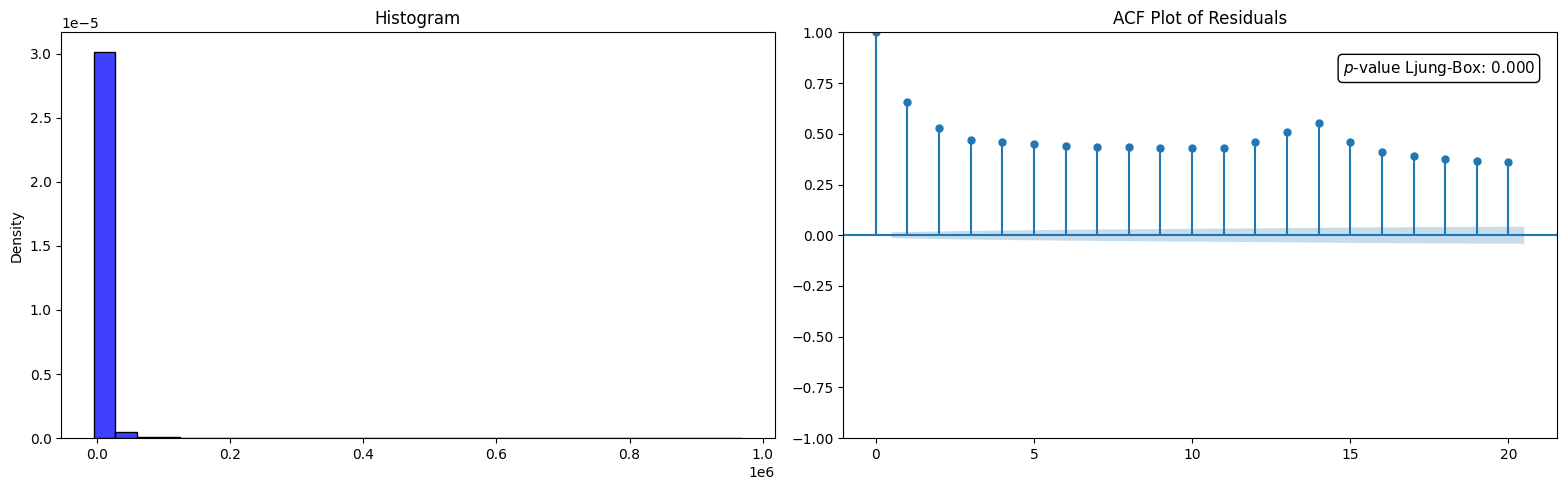

In [159]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_svr, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_svr, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

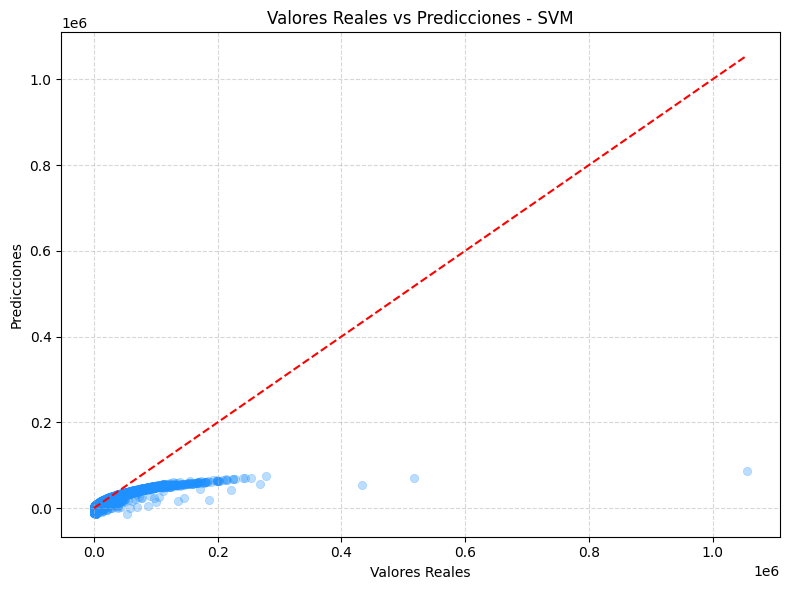

In [161]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_test_svr_pred, alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - SVM")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. MLP

### Ajuste del Modelo

In [15]:
# Se crea el pipeline para MLP
mlp_pipeline = make_pipeline(
    StandardScaler(),    # Normalización de las características
    MLPRegressor(max_iter=1000, random_state=42) # Modelo MLP para regresión
)

In [16]:
# Grid de hiperparámetros para XGBoost
mlp_param_grid = {
    'mlpregressor__hidden_layer_sizes': [(50,), (100,)],
    'mlpregressor__activation': ['tanh'],
    'mlpregressor__alpha': [0.0001, 0.001]
}

In [ ]:
# Realizar GridSearchCV para MLP y guardar mejor modelo
model_filename = 'best_mlp_model.joblib'
model = None

if os.path.exists(model_filename):
    print(f"El modelo ya existe. Cargando desde {model_filename}...")
    model = joblib.load(model_filename)
else:
    print("El modelo no existe. Entrenando un nuevo modelo...")
    mlp_grid_search = GridSearchCV(mlp_pipeline, mlp_param_grid, cv=5)
    start_fit_mlp = time.time()
    mlp_grid_search.fit(X_train, Y_train)
    end_fit_mlp = time.time()

    # Imprimir los mejores parámetros y el rendimiento
    print(f"Mejores parámetros de MLP: {mlp_grid_search.best_params_}")
    print(f"Mejor puntuación de MLP: {mlp_grid_search.best_score_}")
    print(f"Tiempo de cómputo (s): : {round(end_fit_mlp - start_fit_mlp, 4)}")

    joblib.dump(mlp_grid_search.best_estimator_, model_filename)
    print(f"Modelo guardado como {model_filename}")
    
    model = mlp_grid_search.best_estimator_

El modelo no existe. Entrenando un nuevo modelo...


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\lui

Mejores parámetros de Random Forest: {'mlpregressor__activation': 'tanh', 'mlpregressor__alpha': 0.001, 'mlpregressor__hidden_layer_sizes': (100,)}
Mejor puntuación de Random Forest: 0.7480724630296116
Tiempo de cómputo (s): : 6028.1449
Modelo guardado como best_mlp_model.joblib


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
print("Score test: {:.4f}".format(mlp_grid_search.score(X_test, Y_test)))

Score test: 0.6330


### Forecast Accuracy

In [49]:
# Se carga el mejor modelo
best_mlp_model = joblib.load('best_mlp_model.joblib')

In [50]:
y_test_mlp_pred = best_mlp_model.predict(X_test)

In [51]:
forecast_accuracy( np.array(y_test_mlp_pred), np.array(Y_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,1291.60621,8.270107,1.556017e+08,12474.040682


In [ ]:
# Se calcula r^2
r2 = r2_score(Y_test, y_test_mlp_pred)
print(f"R²: {r2:.4f}")

R²: 0.6330


### Gráfica de diagnóstico

In [156]:
# Residuales de modelo
residuals_mlp = Y_test - y_test_mlp_pred

In [157]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_mlp, lags=[144], return_df=True)
print(lb_test)

          lb_stat  lb_pvalue
144  88722.238411        0.0


In [158]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_mlp)

SignificanceResult(statistic=4469592726.67403, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


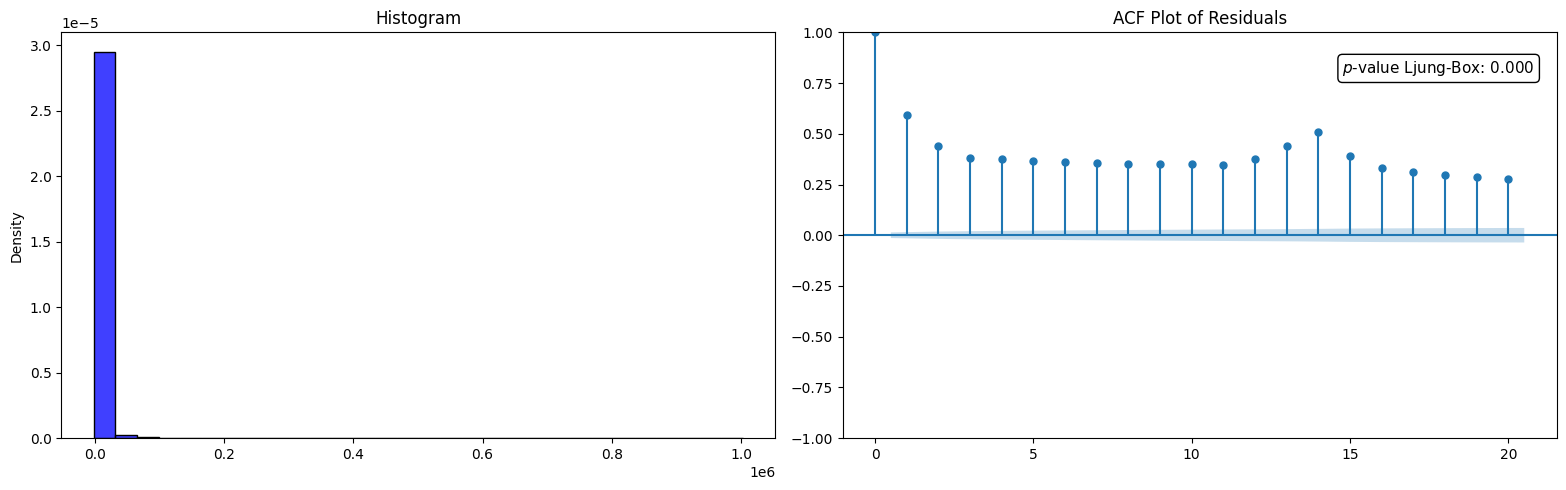

In [159]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_mlp, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_mlp, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

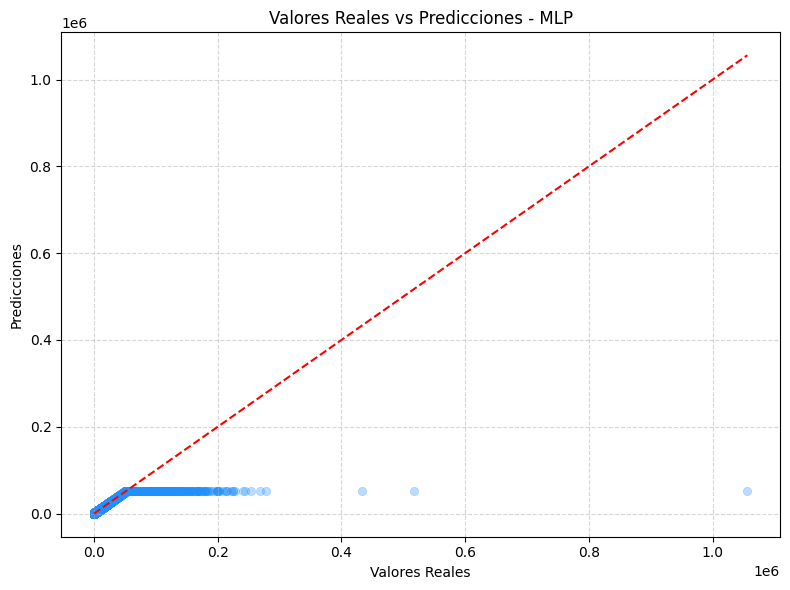

In [161]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_test_mlp_pred, alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - MLP")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Preparación de los datos para Machine Learning

In [169]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Ajustar solo con el conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    
# y necesita reshape para que sea 2D
Y_train_scaled = scaler.fit_transform(Y_train.reshape(-1, 1))

In [170]:
def crear_secuencias(X, y, timesteps):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:(i + timesteps)])
        ys.append(y[i + timesteps])
    return np.array(Xs), np.array(ys)

In [171]:
timesteps = 14
X_seq, Y_seq = crear_secuencias(X_train_scaled, Y_train_scaled, timesteps)

# También preparar test
X_seq_test, Y_seq_test = crear_secuencias(X_test_scaled, Y_test.reshape(-1, 1), timesteps)

In [172]:
# División en train y validación
split_idx = int(len(X_seq) * 0.8)

X_seq_train = X_seq[:split_idx]
Y_seq_train = Y_seq[:split_idx]

X_seq_val = X_seq[split_idx:]
Y_seq_val = Y_seq[split_idx:]

In [173]:
print("Input shape:", X_seq_train.shape)

Input shape: (90626, 14, 7)


In [174]:
X_seq_train = X_seq_train.astype(np.float32)
y_seq_train = Y_seq_train.astype(np.float32)
X_seq_val = X_seq_val.astype(np.float32)
y_seq_val = Y_seq_val.astype(np.float32)

## 9. RNN

### Ajuste del Modelo

In [60]:
# Definimos la red RRN
input_layer = Input(shape=(14, X.shape[1]), dtype='float32')
RRN_layer1 = SimpleRNN(32, activation='tanh')(input_layer)
dropout_layer = Dropout(0.2)(RRN_layer1)
output_layer = Dense(1, activation='linear')(dropout_layer)

In [61]:
# Resumen del modelo RNN
ts_model = Model(inputs=input_layer, outputs=output_layer)
ts_model.compile(loss='mean_squared_error', optimizer='adam')
ts_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 14, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Función para guardar el modelo para la época en la que la función de pérdida ha sido mínima.
save_weights_at = os.path.join('keras_models', 'potencial_RNN_weights14.{epoch:02d}-{val_loss:.4f}.keras')
save_best = [ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=False, mode='min', save_freq='epoch')];

In [63]:
# Se entrena el modelo, se guarda el mejor
history_potencial14_RNN = None

if os.path.exists('history_potencial14_RNN.joblib'):
    history_RNN = load('history_potencial14_RNN.joblib')
    print("El archivo 'history_potencial14_RNN.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    start_fit_rnn = time.time()
    history_potencial14_RNN = ts_model.fit(x=X_seq_train, y=Y_seq_train, batch_size=16, epochs=50,
             verbose=1, callbacks=save_best, validation_data=(X_seq_val, Y_seq_val),
             shuffle=True);
    end_fit_rnn = time.time()
    dump(history_potencial14_RNN.history, 'history_potencial14_RNN.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_potencial14_RNN.joblib'.")
    print(f"Tiempo de cómputo (s): : {round(end_fit_rnn - start_fit_rnn, 4)}")

Epoch 1/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.0133 - val_loss: 3.4360e-04
Epoch 2/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 4.8986e-04 - val_loss: 2.3539e-04
Epoch 3/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 4.4788e-04 - val_loss: 2.5164e-04
Epoch 4/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 4.1281e-04 - val_loss: 2.2939e-04
Epoch 5/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 4.0203e-04 - val_loss: 2.7062e-04
Epoch 6/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 3.8416e-04 - val_loss: 2.2378e-04
Epoch 7/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 4.2634e-04 - val_loss: 4.3565e-04
Epoch 8/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 4.1212e-04 - val_loss: 2.5320e-04
Epoch 9/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 4.3381e-04 - val_loss: 2.3076e-04
Epoch 10/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 3.5598e-04 - val_loss: 2.3760e-04
Epoch 11/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 

### Forescast Accuracy

In [190]:
# Se carga el mejor modelo
model_dir = 'keras_models'
files = os.listdir(model_dir)
pattern = r"potencial_RNN_weights14\.(\d+)-([\d\.]+)\.keras"

best_val_loss = float('inf')
best_model_file = None
best_model_rnn = None

for file in files:
    match = re.match(pattern, file)
    if match:
        epoch = int(match.group(1))
        val_loss = float(match.group(2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_file = file

if best_model_file:
    best_model_path = os.path.join(model_dir, best_model_file)
    print(f"Cargando el mejor modelo: {best_model_file} con val_loss: {best_val_loss}")
    best_model_rnn = load_model(best_model_path)
else:
    print("No se encontraron archivos de modelos que coincidan con el patrón.")

Cargando el mejor modelo: potencial_RNN_weights14.02-0.0002.keras con val_loss: 0.0002


In [191]:
y_test_rnn = best_model_rnn.predict(X_seq_test)
y_test_rnn_pred = scaler.inverse_transform(y_test_rnn)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step


In [192]:
forecast_accuracy( np.array(y_test_rnn_pred), np.array(Y_seq_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,5105.955736,314.666485,1.615946e+08,12711.986565


In [193]:
# Se calcula r^2
r2 = r2_score(Y_seq_test, y_test_rnn_pred)
print(f"R²: {r2:.4f}")

R²: 0.6190


### Gráfica de diagnóstico

In [67]:
# Residuales de modelo
residuals_rnn = Y_seq_test - y_test_rnn_pred

In [68]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_rnn, lags=[144], return_df=True)
print(lb_test)

          lb_stat  lb_pvalue
144  12747.317071        0.0


In [69]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_rnn)

SignificanceResult(statistic=4049957469.507108, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


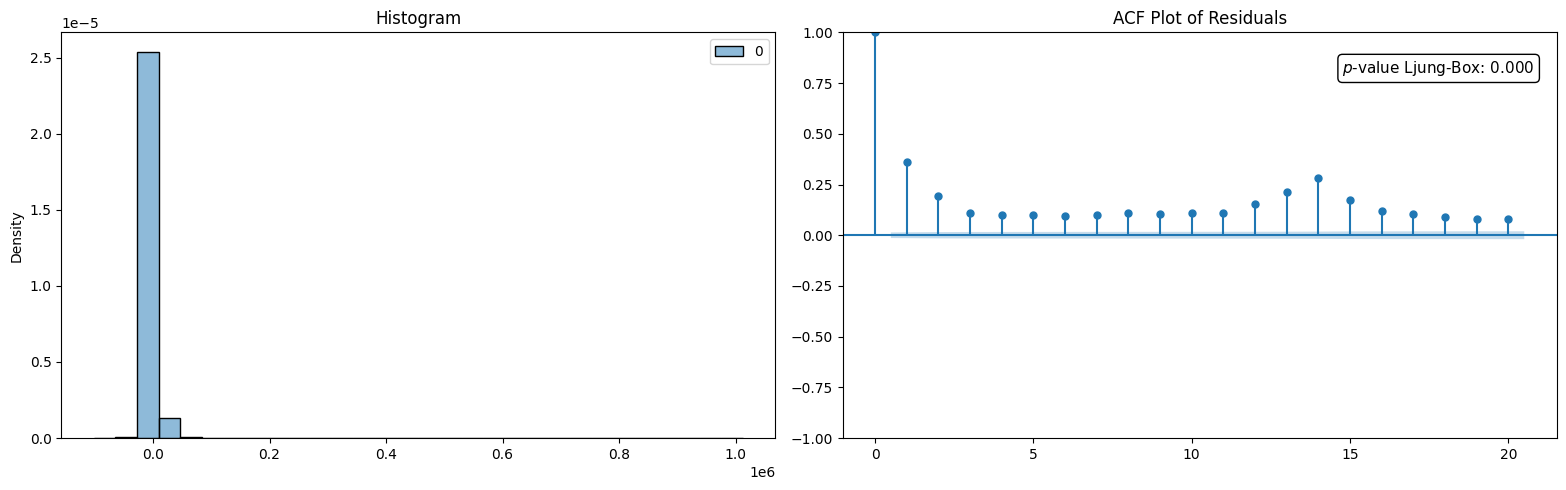

In [70]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_rnn, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_rnn, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

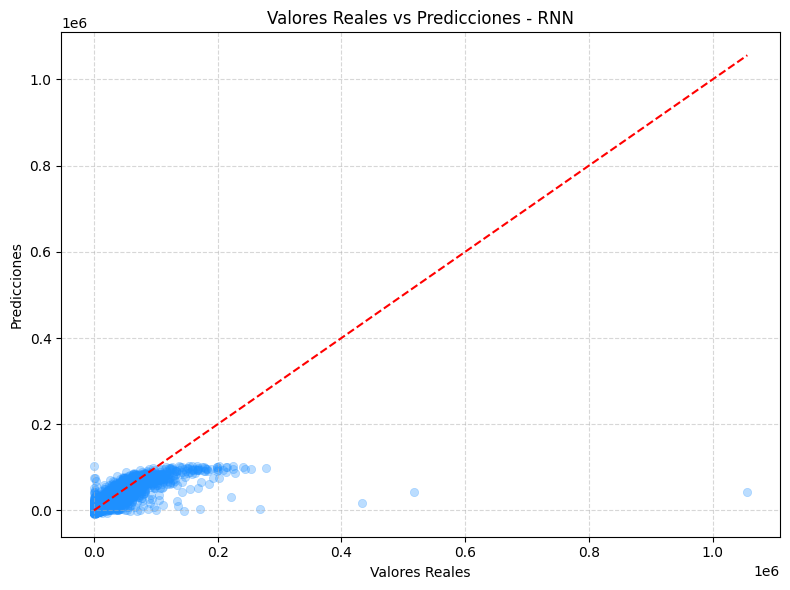

In [71]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test[14:], y=y_test_rnn_pred.flatten(), alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - RNN")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

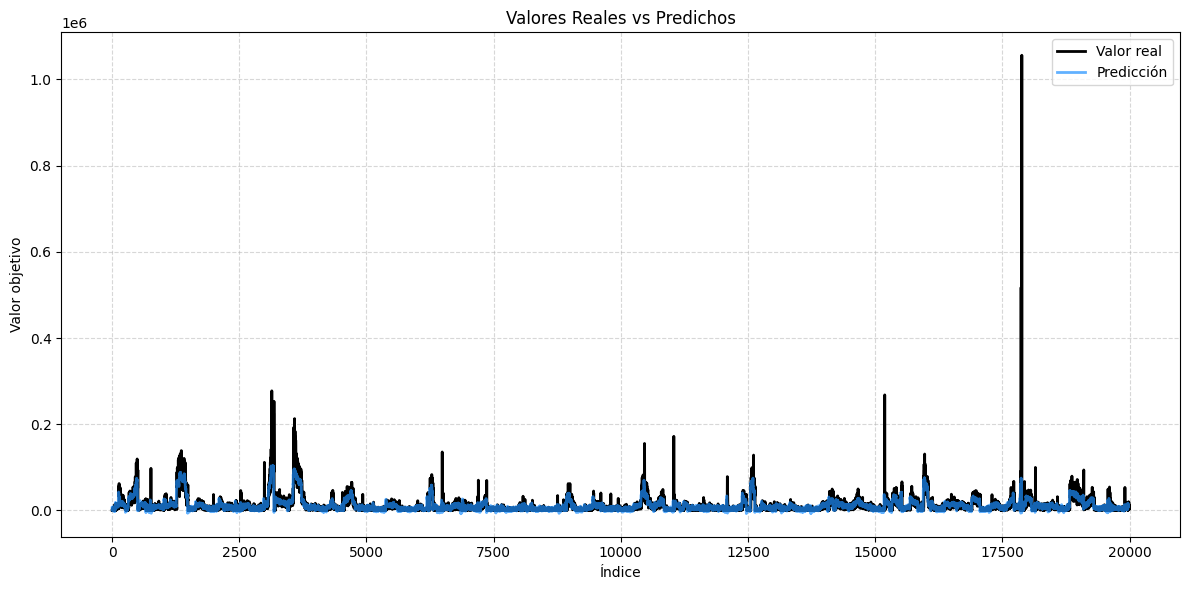

In [ ]:
# Gráfica de predichos y observados vs índice
plt.figure(figsize=(12, 6))

# Dibujamos los valores reales
plt.plot(Y_test, label='Valor real', linewidth=2, color='black')

# Dibujamos las predicciones
plt.plot(y_test_rnn_pred, label='Predicción', linewidth=2, alpha=0.7, color='dodgerblue')

plt.title("Valores Reales vs Predichos")
plt.xlabel("Índice")
plt.ylabel("Valor objetivo")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. LSTM

### Ajuste del Modelo

In [73]:
# Definimos la red LSTM
input_layer = Input(shape=(X_seq_train.shape[1],X_seq_train.shape[2]), dtype='float32')
lstm_layer1 = LSTM(64, input_shape=(X_seq_train.shape[1],X_seq_train.shape[2]), return_sequences=True)(input_layer)
lstm_layer2 = LSTM(32, input_shape=(X_seq_train.shape[1],64), return_sequences=False)(lstm_layer1)
dropout_layer = Dropout(0.2)(lstm_layer2)
output_layer = Dense(1, activation='linear')(dropout_layer)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [74]:
# Resumen del modelo LSTM
lstm_model = Model(inputs=input_layer, outputs=output_layer)
lstm_model.compile(loss='mean_absolute_error', optimizer='adam') #SGD(lr=0.001, decay=1e-5))
lstm_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 14, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 14, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Función para guardar el modelo para la época en la que la función de pérdida ha sido mínima.
save_weights_at = os.path.join('keras_models', 'potencial_LSTM_weights14.{epoch:02d}-{val_loss:.4f}.keras')
save_best = [ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=False, mode='min', save_freq='epoch')];

In [76]:
# Se entrena el modelo, se guarda el mejor
history_potencial14_LSTM = None

if os.path.exists('history_potencial14_LSTM.joblib'):
    history_lstm = load('history_potencial14_LSTM.joblib')
    print("El archivo 'history_potencial14_LSTM.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    start_fit_lstm = time.time()
    history_potencial14_LSTM = lstm_model.fit(x=X_seq_train, y=Y_seq_train, batch_size=16, epochs=50,
             verbose=1, callbacks=save_best, validation_data=(X_seq_val, Y_seq_val),
             shuffle=True);
    end_fit_lstm = time.time()
    dump(history_potencial14_LSTM.history, 'history_potencial14_LSTM.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_potencial14_LSTM.joblib'.")
    print(f"Tiempo de cómputo (s): : {round(end_fit_lstm - start_fit_lstm, 4)}")

Epoch 1/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 0.0126 - val_loss: 0.0081
Epoch 2/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0088 - val_loss: 0.0079
Epoch 3/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 0.0084 - val_loss: 0.0080
Epoch 4/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 0.0084 - val_loss: 0.0084
Epoch 5/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0085 - val_loss: 0.0080
Epoch 6/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0084 - val_loss: 0.0083
Epoch 7/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.0084 - val_loss: 0.0081
Epoch 8/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0082 - val_loss: 0.0087
Epoch 9/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.0084 - val_loss: 0.0083
Epoch 10/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.0083 - val_loss: 0.0081
Epoch 11/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.0083 - val_loss: 0.0081
Epoch 12/50
5665/56

### Forecast Accuracy

In [194]:
# Se carga el mejor modelo
model_dir = 'keras_models'
files = os.listdir(model_dir)
pattern = r"potencial_LSTM_weights14\.(\d+)-([\d\.]+)\.keras"

best_val_loss = float('inf')
best_model_file = None
best_model_lstm = None

for file in files:
    match = re.match(pattern, file)
    if match:
        epoch = int(match.group(1))
        val_loss = float(match.group(2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_file = file

if best_model_file:
    best_model_path = os.path.join(model_dir, best_model_file)
    print(f"Cargando el mejor modelo: {best_model_file} con val_loss: {best_val_loss}")
    best_model_lstm = load_model(best_model_path)
else:
    print("No se encontraron archivos de modelos que coincidan con el patrón.")

Cargando el mejor modelo: potencial_LSTM_weights14.17-0.0078.keras con val_loss: 0.0078


In [195]:
y_test_lstm = best_model_lstm.predict(X_seq_test)
y_test_lstm_pred = scaler.inverse_transform(y_test_lstm)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [196]:
forecast_accuracy( np.array(y_test_lstm_pred), np.array(Y_seq_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,4257.50015,168.339701,1.472640e+08,12135.239684


In [197]:
# Se calcula r^2
r2 = r2_score(Y_seq_test, y_test_lstm_pred)
print(f"R²: {r2:.4f}")

R²: 0.6528


### Gráfica de diagnóstico

In [198]:
# Residuales de modelo
residuals_lstm = Y_seq_test - y_test_lstm_pred

In [85]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_lstm, lags=[144], return_df=True)
print(lb_test)

          lb_stat  lb_pvalue
144  28352.030069        0.0


In [86]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_lstm)

SignificanceResult(statistic=1071222676.3832703, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


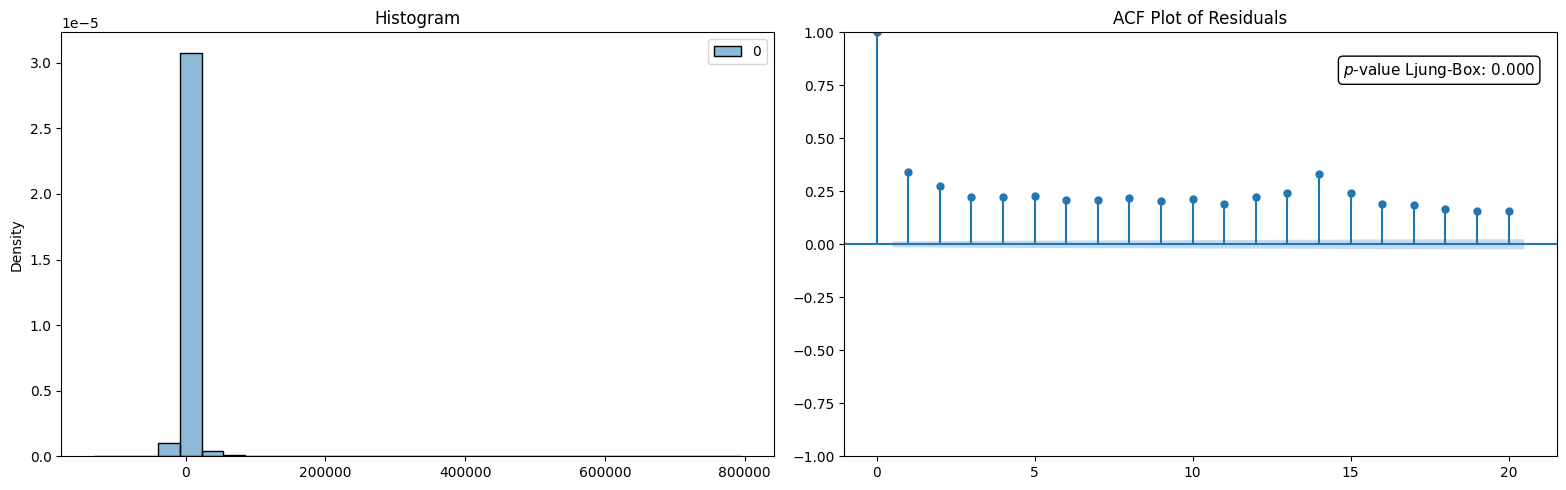

In [87]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_lstm, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_lstm, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

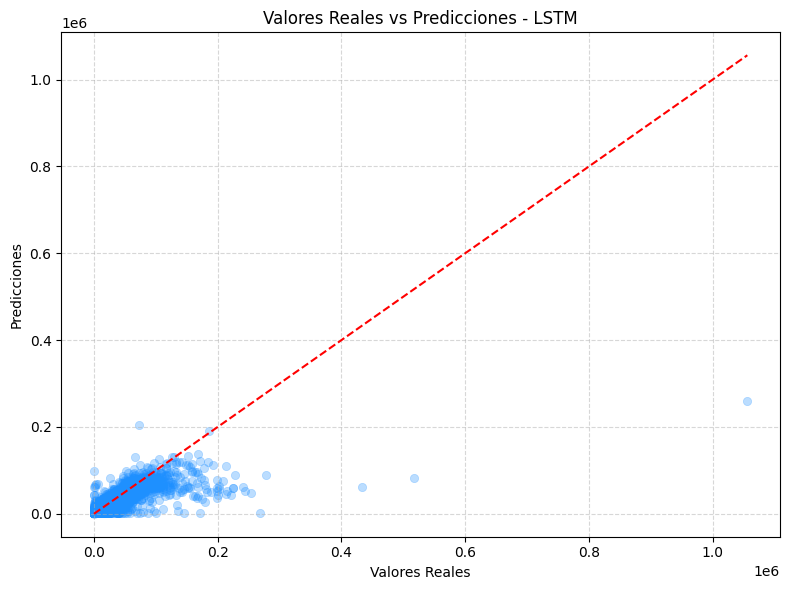

In [88]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test[14:], y=y_test_lstm_pred.flatten(), alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - LSTM")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

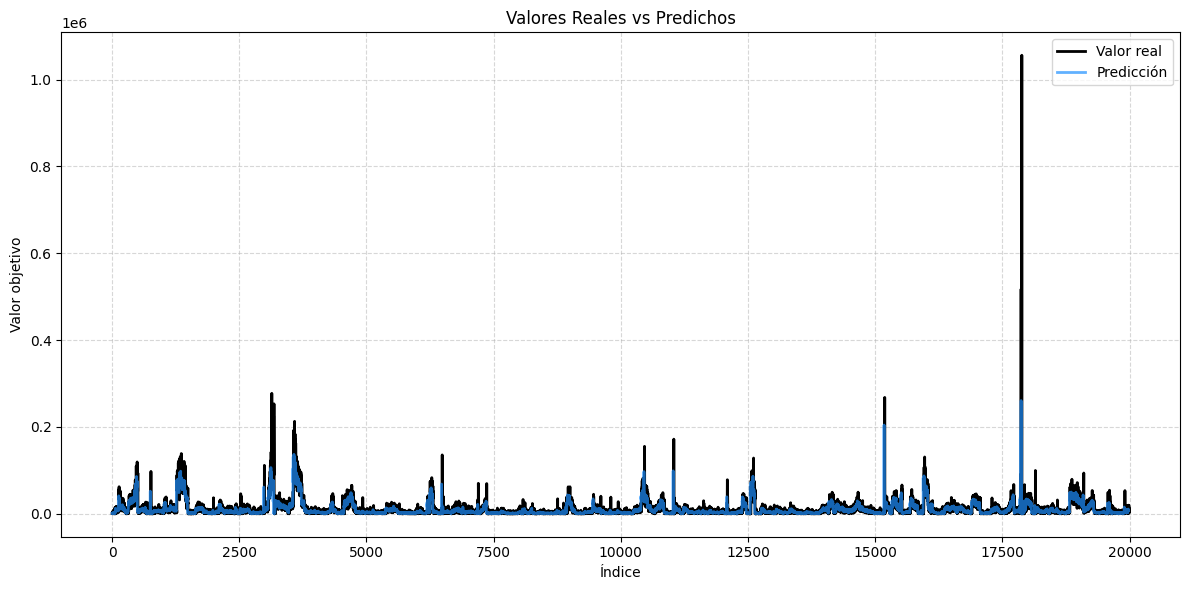

In [199]:
# Gráfica de predichos y observados vs índice
plt.figure(figsize=(12, 6))

# Dibujamos los valores reales
plt.plot(Y_test, label='Valor real', linewidth=2, color='black')

# Dibujamos las predicciones
plt.plot(y_test_lstm_pred, label='Predicción', linewidth=2, alpha=0.7, color='dodgerblue')

plt.title("Valores Reales vs Predichos")
plt.xlabel("Índice")
plt.ylabel("Valor objetivo")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 11. CNN

### Ajuste del Modelo

In [24]:
# Modelo CNN
def crear_modelo_cnn(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='tanh', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Conv1D(filters=64, kernel_size=3, activation='tanh'))
    model.add(Flatten())
    model.add(Dense(50, activation='tanh'))
    model.add(Dense(1))  # Salida regresiva
    model.compile(optimizer='adam', loss='mse')
    return model

In [25]:
input_shape = X_seq_train.shape[1:]

In [26]:
# Crear modelo
model_cnn = crear_modelo_cnn(input_shape)
model_cnn.summary()

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 12, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        32,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,861 (179.14 KB)

 Trainable params: 45,861 (179.14 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Esto sirve  para guardar el modelo para la época en la que la función de pérdida ha sido mínima.
save_weights_at = os.path.join('keras_models', 'potencial_CNN_weights14.{epoch:02d}-{val_loss:.4f}.keras')
checkpointer = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint( save_weights_at, monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=False, mode='min', save_freq='epoch')
]

In [28]:
# Se entrena el modelo, se guarda el mejor
history_CNN14 = None

if os.path.exists('history_CNN14.joblib'):
    history_cnn = load('history_CNN14.joblib')
    print("El archivo 'history_CNN14.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    start_fit_cnn = time.time()
    history_CNN14 = model_cnn.fit(X_seq_train, y_seq_train, validation_data=(X_seq_val, y_seq_val), epochs=50,
                batch_size=32,  callbacks=checkpointer, verbose=1)
    end_fit_cnn = time.time()
    dump(history_CNN14.history, 'history_CNN14.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_CNN14.joblib'.")
    print(f"Tiempo de cómputo (s): : {round(end_fit_cnn - start_fit_cnn, 4)}")

Epoch 1/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0092 - val_loss: 3.4965e-04
Epoch 2/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.9592e-04 - val_loss: 2.7511e-04
Epoch 3/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.3898e-04 - val_loss: 3.3781e-04
Epoch 4/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5.0457e-04 - val_loss: 2.3369e-04
Epoch 5/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4.3089e-04 - val_loss: 2.2458e-04
Epoch 6/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.7797e-04 - val_loss: 2.4376e-04
Epoch 7/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.8859e-04 - val_loss: 2.3435e-04
Epoch 8/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4.0431e-04 - val_loss: 2.1400e-04
Epoch 9/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3.5299e-04 - val_loss: 3.2312e-04
Epoch 10/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4.3563e-04 - val_loss: 2.2876e-04
Epoch 11/50
2833/2833 ━━━━━━━━━━━━━━━━━━━━ 

### Forecast Accuracy

In [200]:
# Se carga el mejor modelo
model_dir = 'keras_models'
files = os.listdir(model_dir)
pattern = r"potencial_CNN_weights14\.(\d+)-([\d\.]+)\.keras"

best_val_loss = float('inf')
best_model_file = None
best_model_cnn = None

for file in files:
    match = re.match(pattern, file)
    if match:
        epoch = int(match.group(1))
        val_loss = float(match.group(2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_file = file

if best_model_file:
    best_model_path = os.path.join(model_dir, best_model_file)
    print(f"Cargando el mejor modelo: {best_model_file} con val_loss: {best_val_loss}")
    best_model_cnn = load_model(best_model_path)
else:
    print("No se encontraron archivos de modelos que coincidan con el patrón.")

Cargando el mejor modelo: potencial_CNN_weights14.04-0.0002.keras con val_loss: 0.0002


In [201]:
y_test_cnn = best_model_cnn.predict(X_seq_test)
y_test_cnn_pred = scaler.inverse_transform(y_test_cnn)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 841us/step


In [202]:
forecast_accuracy( np.array(y_test_cnn_pred), np.array(Y_seq_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,4683.753952,170.89521,1.554453e+08,12467.77124


In [203]:
# Se calcula r^2
r2 = r2_score(Y_seq_test, y_test_cnn_pred)
print(f"R²: {r2:.4f}")

R²: 0.6335


### Gráfica de diagnóstico

In [204]:
# Residuales de modelo
residuals_cnn = Y_seq_test - y_test_cnn_pred

In [363]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_cnn, lags=[144], return_df=True)
print(lb_test)

         lb_stat  lb_pvalue
144  6371.861242        0.0


In [364]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_cnn)

SignificanceResult(statistic=5943023451.041763, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


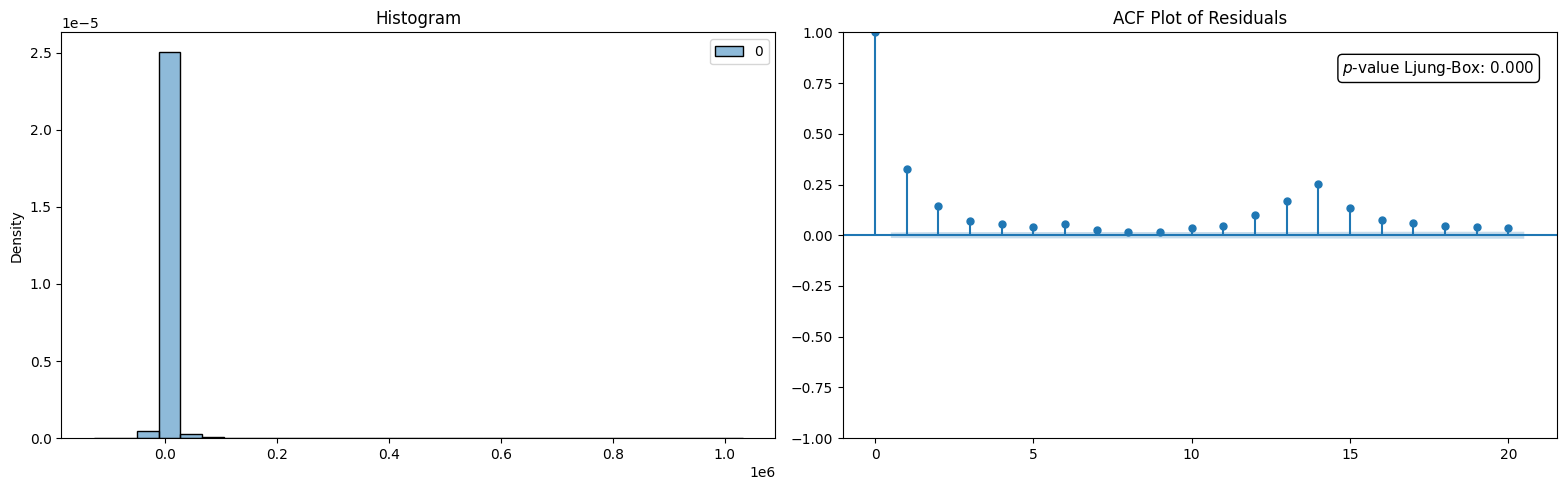

In [365]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_cnn, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_cnn, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Gráfica de predichos vs observados

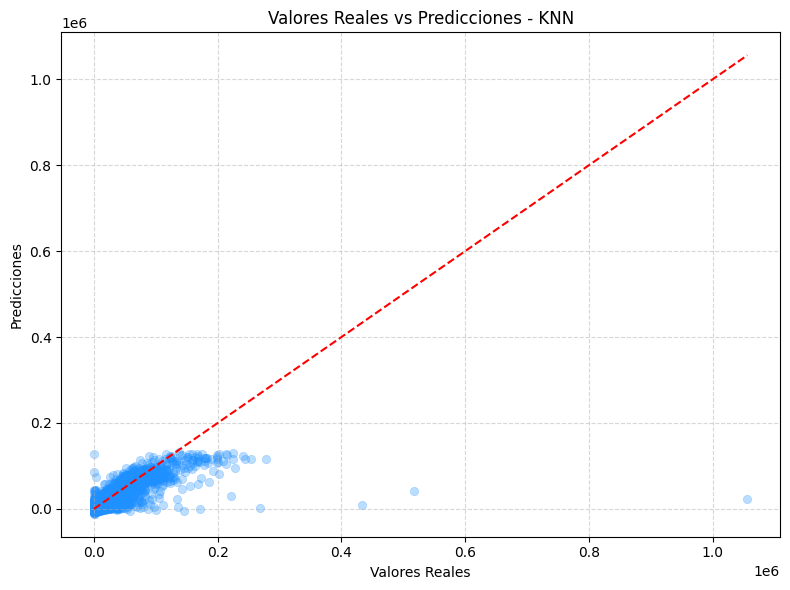

In [367]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test[14:], y=y_test_cnn_pred.flatten(), alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - KNN")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


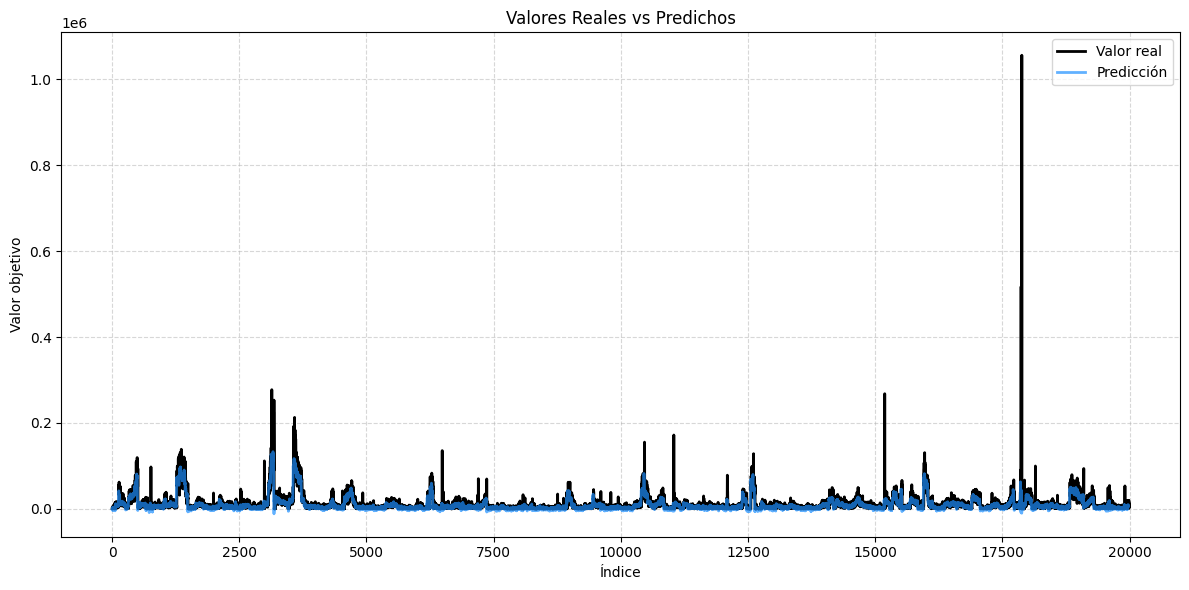

In [368]:
# Gráfica de predichos y observados vs índice
plt.figure(figsize=(12, 6))

# Dibujamos los valores reales
plt.plot(Y_test, label='Valor real', linewidth=2, color='black')

# Dibujamos las predicciones
plt.plot(y_test_cnn_pred, label='Predicción', linewidth=2, alpha=0.7, color='dodgerblue')

plt.title("Valores Reales vs Predichos")
plt.xlabel("Índice")
plt.ylabel("Valor objetivo")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Modelo Original - A-BILSTM

### Ajuste del Modelo

In [78]:
# Definimos la red A-BILSTM
input_layer = Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2]))
bi_lstm_out = Bidirectional(LSTM(64, input_shape = (X_seq_train.shape[1],X_seq_train.shape[2]), return_sequences=True))(input_layer)

# Mecanismo de atención
query = Dense(128)(bi_lstm_out)  # Query de las salidas de LSTM
key = Dense(128)(bi_lstm_out)    # Key de las salidas de LSTM
attention = Attention()([query, key])  # Se calculan los puntajes de atención

# Aplica pesos de atención a las salidas de BILSTM
attention_out = Multiply()([bi_lstm_out, attention])

dense_out = Dense(32, activation="relu")(attention_out[:, -1, :])  # Select last time step
dropout_layer = Dropout(0.2)(dense_out)
output_layer = Dense(1)(dropout_layer) 

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [79]:
# Resumen del modelo A-BILSTM
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer="adam", loss="mean_absolute_error")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 14, 7)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 14, 128)   │     36,864 │ input_layer_1[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 14, 128)   │     16,512 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 14, 128)   │     16,512 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 14, 128)   │          0 │ dense_4[0][0],    │
│ (Attention)         │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 14, 128)   │          0 │ bidirectional_1[… │
│ (Multiply)          │                   │            │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128)       │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      4,128 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 74,049 (289.25 KB)

 Trainable params: 74,049 (289.25 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# Esto sirve  para guardar el modelo para la época en la que la función de pérdida ha sido mínima.
save_weights_at = os.path.join('keras_models', 'potencial_bilstm_weights.{epoch:02d}-{val_loss:.4f}.keras')
save_best = [ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=False, mode='min', save_freq='epoch')];

In [82]:
# Se entrena el modelo, se guarda el mejor
history_potencial_BILSTM = None

if os.path.exists('history_potencial_BILSTM.joblib'):
    history_bilstm = load('history_potencial_BILSTM.joblib')
    print("El archivo 'history_potencial_BILSTM.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    start_fit_bilstm = time.time()
    history_potencial_BILSTM = model.fit(x=X_seq_train, y=Y_seq_train, batch_size=16, epochs=50,
             verbose=1, callbacks=save_best, validation_data=(X_seq_val, Y_seq_val),
             shuffle=True);
    end_fit_bilstm = time.time()
    dump(history_potencial_BILSTM.history, 'history_potencial_BILSTM.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_potencial_BILSTM.joblib'.")
    print(f"Tiempo de cómputo (s): : {round(end_fit_bilstm - start_fit_bilstm, 4)}")

Epoch 1/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 0.0097 - val_loss: 0.0084
Epoch 2/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.0088 - val_loss: 0.0092
Epoch 3/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 0.0088 - val_loss: 0.0085
Epoch 4/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 0.0087 - val_loss: 0.0081
Epoch 5/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.0087 - val_loss: 0.0085
Epoch 6/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.0086 - val_loss: 0.0079
Epoch 7/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.0087 - val_loss: 0.0078
Epoch 8/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.0085 - val_loss: 0.0083
Epoch 9/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 0.0085 - val_loss: 0.0080
Epoch 10/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 0.0086 - val_loss: 0.0083
Epoch 11/50
5665/5665 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 0.0084 - val_loss: 0.0079
Epoch 12/50
5665/56

### Forecast Accuracy

In [184]:
# Se carga el mejor modelo
model_dir = 'keras_models'
files = os.listdir(model_dir)
pattern = r"potencial_bilstm_weights\.(\d+)-([\d\.]+)\.keras"

best_val_loss = float('inf')
best_model_file = None
best_model_bilstm = None

for file in files:
    match = re.match(pattern, file)
    if match:
        epoch = int(match.group(1))
        val_loss = float(match.group(2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_file = file

if best_model_file:
    best_model_path = os.path.join(model_dir, best_model_file)
    print(f"Cargando el mejor modelo: {best_model_file} con val_loss: {best_val_loss}")
    best_model_bilstm = load_model(best_model_path)
else:
    print("No se encontraron archivos de modelos que coincidan con el patrón.")

Cargando el mejor modelo: potencial_bilstm_weights.35-0.0076.keras con val_loss: 0.0076


In [185]:
y_test_bilstm = best_model_bilstm.predict(X_seq_test)
y_test_bilstm_pred = scaler.inverse_transform(y_test_bilstm)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [186]:
forecast_accuracy( np.array(y_test_bilstm_pred), np.array(Y_seq_test), "Value")

,MAE,MAPE,MSE,RMSE
Value,4015.221714,151.423012,1.193319e+08,10923.912717


In [187]:
# Se calcula r^2
r2 = r2_score(Y_seq_test, y_test_bilstm_pred)
print(f"R²: {r2:.4f}")

R²: 0.7187


### Gráfica de diagnóstico

In [126]:
# Residuales de modelo
residuals_bilstm = Y_seq_test - y_test_bilstm_pred

In [131]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_bilstm, lags=[144], return_df=True)
print(lb_test)

         lb_stat      lb_pvalue
144  1795.715429  7.065635e-283


In [130]:
# Se hace la prueba de Jarque-Bera para la normalidad en los residuales
stats.jarque_bera(residuals_bilstm)

SignificanceResult(statistic=2557282797.0963545, pvalue=0.0)

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


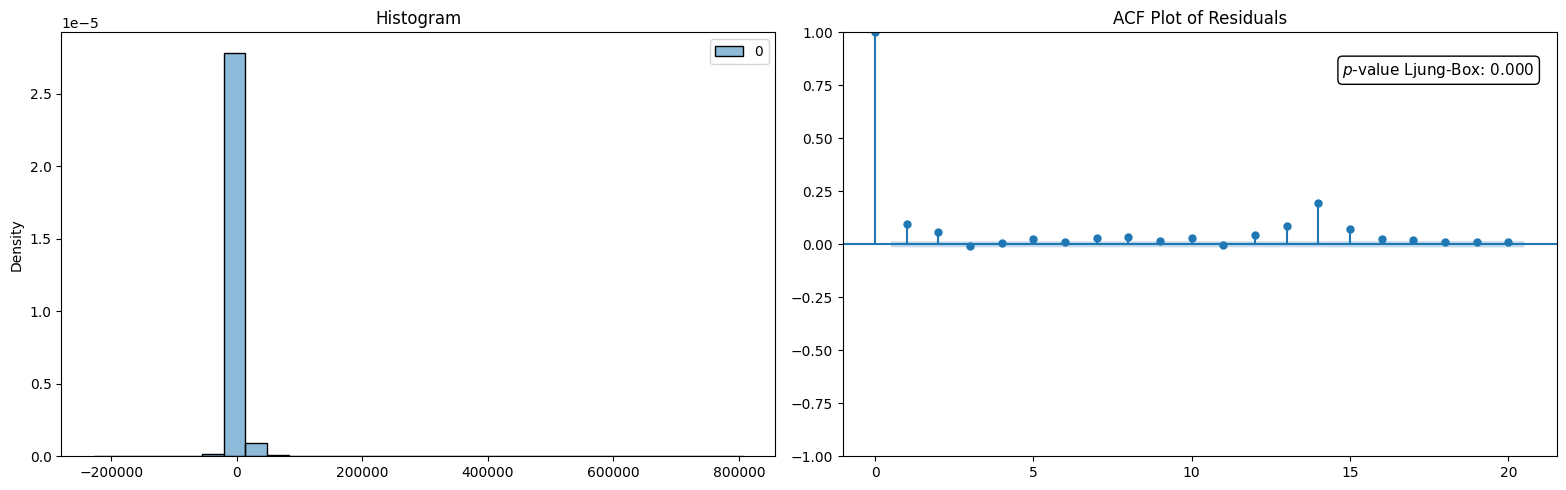

In [102]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histograma
sns.histplot(residuals_bilstm, stat="density", bins=30, kde=False, ax=axes[0], color="blue")
axes[0].set_title("Histogram")

# Plot 2: ACF
sm.graphics.tsa.plot_acf(residuals_bilstm, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.7, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()


### Gráfica de predichos vs observados

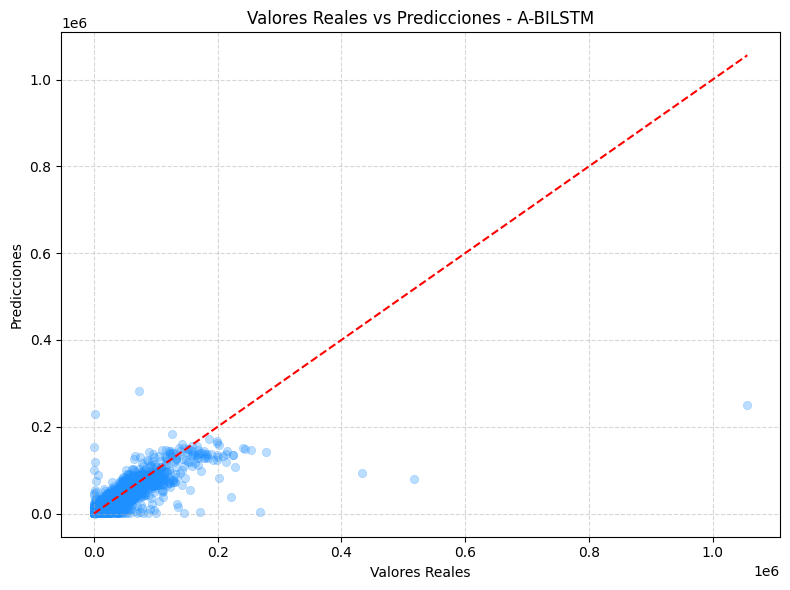

In [188]:
# Gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test[14:], y=y_test_bilstm_pred.flatten(), alpha=0.3, color='dodgerblue', edgecolor=None)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # línea ideal
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones - A-BILSTM")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

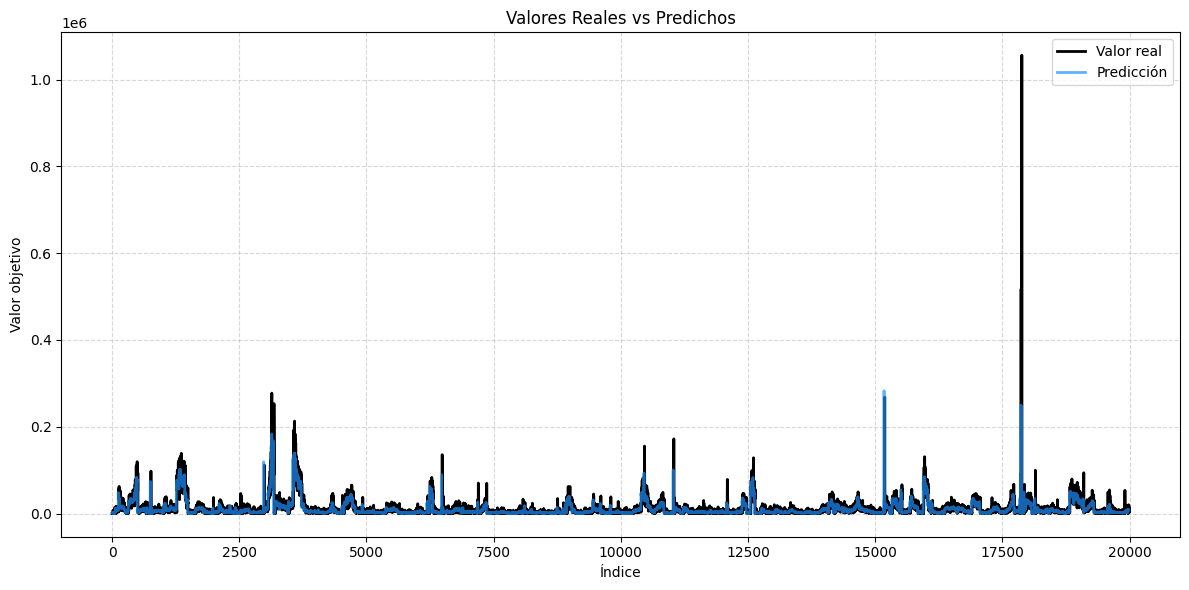

In [189]:
# Gráfica de predichos y observados vs índice
plt.figure(figsize=(12, 6))

# Dibujamos los valores reales
plt.plot(Y_test, label='Valor real', linewidth=2, color='black')

# Dibujamos las predicciones
plt.plot(y_test_bilstm_pred, label='Predicción', linewidth=2, alpha=0.7, color='dodgerblue')

plt.title("Valores Reales vs Predichos")
plt.xlabel("Índice")
plt.ylabel("Valor objetivo")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()